# FGBG Seperation via Color Pixel Mask and Red Sequence Members 

### Imports

In [18]:
from astropy.table import Table, vstack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy import ndimage
from matplotlib.colors import to_rgba
import matplotlib.cm as cm
import sys
from scipy.ndimage import gaussian_filter
import os

from sklearn.model_selection import StratifiedKFold
from contextlib import redirect_stdout
import io

### Load in Redshift Data and the Full Cluster Catalog

In [2]:
# Data file paths
REDSHIFT_CATALOG = '/scratch/sa.saha/data/mega_color_mag_with_redshift_20250811_141642.fits'  # Training data with known redshifts
FULL_CATALOG = '/scratch/sa.saha/data/mega_color_mag_catalog_20250811_141158.fits'            # Full catalog

CORRECTED_REDSHIFT_CATALOG = '/projects/mccleary_group/amit.m/dust/dust/mega_corrected_catalog_with_redshift.fits'
CORRECTED_FULL_CATALOG = '/projects/mccleary_group/amit.m/dust/dust/mega_corrected_catalog.fits'

# Load the redshift catalog (for visualization and validation)
print("Loading redshift catalog for training/validation...")
redshift_cat = Table.read(CORRECTED_REDSHIFT_CATALOG)
print(f"Loaded {len(redshift_cat)} objects with known redshifts")

# Load the full catalog (for applying cuts)
print("\nLoading full photometric catalog...")
full_cat = Table.read(CORRECTED_FULL_CATALOG)
print(f"Loaded {len(full_cat)} total objects")

# Display available columns
print(f"\nAvailable columns: {full_cat.colnames}")

Loading redshift catalog for training/validation...
Loaded 22031 objects with known redshifts

Loading full photometric catalog...
Loaded 249978 total objects

Available columns: ['FLUXERR_AUTO_b', 'FLUXERR_AUTO_g', 'FLUXERR_AUTO_u', 'FLUX_AUTO_b', 'FLUX_AUTO_g', 'FLUX_AUTO_u', 'OBJTYPE', 'PROGRAM', 'R_b', 'R_b_prepsf', 'R_g', 'R_g_prepsf', 'R_u', 'R_u_prepsf', 'SNR_b', 'SNR_combined', 'SNR_g', 'SNR_u', 'SPECTYPE', 'SURVEY', 'TARGETID', 'TARGET_DEC', 'TARGET_RA', 'VIGNET_b', 'VIGNET_g', 'VIGNET_u', 'Z', 'ZCAT_NSPEC', 'ZCAT_PRIMARY', 'ZERR', 'ZERR_best', 'ZERR_desi', 'ZERR_lovoccs', 'ZWARN', 'Z_best', 'Z_desi', 'Z_lovoccs', 'Z_ned', 'Z_source', 'color_bg', 'color_bg_err', 'color_ub', 'color_ub_err', 'dec', 'id', 'm_b', 'm_b_err', 'm_g', 'm_g_err', 'm_u', 'm_u_err', 'ra', 'CLUSTER', 'm_u_corr_csfd', 'm_b_corr_csfd', 'm_g_corr_csfd', 'corr_color_ub', 'corr_color_bg']


### Define Variables

In [3]:
redshift = redshift_cat['Z_best'].astype(float)
color_bg = redshift_cat['corr_color_bg'].astype(float)  # B-G color *includes lovoccs*
color_ub = redshift_cat['corr_color_ub'].astype(float)  # U-B color
color_bg_err = redshift_cat['color_bg_err'].astype(float)
color_ub_err = redshift_cat['color_ub_err'].astype(float)
redshift_err = redshift_cat["ZERR_best"].astype(float)
redshift_source = np.array([s.strip() for s in redshift_cat['Z_source']])

color_bg_full = full_cat['corr_color_bg'].astype(float)  # B-G color *includes lovoccs*
color_ub_full = full_cat['corr_color_ub'].astype(float)  # U-B color
color_bg_err_full = full_cat['color_bg_err'].astype(float)
color_ub_err_full = full_cat['color_ub_err'].astype(float)


print("Data summary:")
print(f"Redshift range: {np.nanmin(redshift):.3f} to {np.nanmax(redshift):.3f}")
print(f"B-G color range: {np.nanmin(color_bg):.3f} to {np.nanmax(color_bg):.3f}")
print(f"U-B color range: {np.nanmin(color_ub):.3f} to {np.nanmax(color_ub):.3f}")
print(f"Redshift sources: {np.unique(redshift_source)}")

Data summary:
Redshift range: -0.001 to 6.640
B-G color range: -86.265 to 79.563
U-B color range: -79.174 to 86.826
Redshift sources: ['DESI' 'LoVoCCS' 'NED']


### Load in the red sequence data 


In [4]:
# Red Sequence Members 

# Redshift: 0.193
Abell3411_imposters = Table.read('/projects/mccleary_group/ysp/redseq/Abell3411/Abell3411_imposter_members_catalog.fits')
Abell3411_actual = Table.read('/projects/mccleary_group/ysp/redseq/Abell3411/Abell3411_actual_members_catalog.fits')

# Redshift: 0.3
Bullet_imposters = Table.read('/projects/mccleary_group/ysp/redseq/1E0657_Bullet/1E0657_Bullet_imposter_members_catalog.fits')
Bullet_actual = Table.read('/projects/mccleary_group/ysp/redseq/1E0657_Bullet/1E0657_Bullet_actual_members_catalog.fits')

# Redshift: 0.18
Abell1689_imposters = Table.read('/projects/mccleary_group/ysp/redseq/Abell1689/Abell1689_imposter_members_catalog.fits')
Abell1689_actual = Table.read('/projects/mccleary_group/ysp/redseq/Abell1689/Abell1689_actual_members_catalog.fits')

# Redshfit: 0.22
AbellS0592_imposters = Table.read('/projects/mccleary_group/ysp/redseq/AbellS0592/AbellS0592_imposter_members_catalog.fits')
AbellS0592_actual = Table.read('/projects/mccleary_group/ysp/redseq/AbellS0592/AbellS0592_actual_members_catalog.fits')

# Redshift: 0.33
SMACSJ2031d8m4036_imposters = Table.read('/projects/mccleary_group/ysp/redseq/SMACSJ2031d8m4036/SMACSJ2031d8m4036_imposter_members_catalog.fits')
SMACSJ2031d8m4036_actual = Table.read('/projects/mccleary_group/ysp/redseq/SMACSJ2031d8m4036/SMACSJ2031d8m4036_actual_members_catalog.fits')

### Define Cluster and General Parameters

In [20]:
Z_THRESH = 0.17
ERR_THRESH = 0.5
CLUSTER_NAME = 'Abell3411'
XLIM = (0,2.5) #(-0.5, 3)    
YLIM = (-2, 2.5) #(-2, 3) 
PIXEL_SIZE = 0.05
PURITY_THRESHOLD = 0.5
MIN_COUNT = 10
FG_Path = "/projects/mccleary_group/amit.m/dust" # Where you wanna save to!!!!!! 


In [6]:
# Valid redshift sources (NED and DESI are most reliable)
reliable_sources_mask = (redshift_source == "NED" ) | (redshift_source == "DESI") 

# Good color measurements (low errors)
good_colors_mask = (color_bg_err < ERR_THRESH) & (color_ub_err < ERR_THRESH)

# No NaN values in colors or redshift
valid_data_mask = ~(np.isnan(color_bg) | np.isnan(color_ub) | np.isnan(redshift))

# Combined mask for "training"
training_mask = reliable_sources_mask & good_colors_mask & valid_data_mask

# Background vs foreground classification
background_mask = redshift > Z_THRESH  # Objects behind the cluster
foreground_mask = redshift < Z_THRESH  # Objects in front of the cluster

# data quality stats
total_objects = len(redshift)
nan_objects = np.sum(~valid_data_mask)
high_error_objects = np.sum(~good_colors_mask & valid_data_mask)  # Valid data but high errors!
unreliable_sources = np.sum(~reliable_sources_mask)

## Pixel Mask Functions

In [7]:
def create_pixel_voting_map_purity(color_bg, color_ub, redshift, z_thresh, xlim, ylim,
                                   pixel_size, purity_threshold, training_mask=None,
                                   weighting=True, color_bg_err=None, color_ub_err=None):
    """
    Create a pixel-based voting map in color-color space with purity threshold.
    Each pixel is colored based on whether foreground (blue) objects meet the purity threshold.
    
    Parameters
    ----------
    color_bg, color_ub : array-like
        B-G and U-B colors
    redshift : array-like
        Redshift values
    z_thresh : float
        Redshift threshold for background/foreground split
    xlim, ylim : tuple
        Plot limits for color axes
    pixel_size : float
        Size of each pixel in color space
    purity_threshold : float
        Minimum fraction of foreground objects needed for pixel to be blue
    training_mask : boolean array, optional
        Mask for high-quality training data
    weighting : bool, optional
        If True, use variance-based weighting with color errors
    color_bg_err, color_ub_err : array-like, optional
        Color errors for B-G and U-B (required if weighting=True)
    
    Returns
    -------
    vote_map : 2D array
        Voting results: 1 for red (background-dominated or below purity),
        -1 for blue (foreground purity >= threshold)
    x_edges, y_edges : array
        Bin edges for the pixel grid
    bg_hist, fg_hist : 2D arrays
        Object counts (or weighted sums) for background and foreground populations
    total_objects : 2D array
        Total weighted sum (or counts if no weighting) per pixel
    actual_counts : 2D array
        Actual object counts per pixel (always unweighted)
    """
    
    # Handle weighting parameter validation
    if weighting and (color_bg_err is None or color_ub_err is None):
        raise ValueError("color_bg_err and color_ub_err must be provided when weighting=True")
    
    # Apply training mask if provided
    if training_mask is not None:
        cb = color_bg[training_mask]
        cub = color_ub[training_mask]
        z = redshift[training_mask]
        if weighting:
            cb_err = color_bg_err[training_mask]
            cub_err = color_ub_err[training_mask]
    else:
        cb, cub, z = color_bg, color_ub, redshift
        if weighting:
            cb_err, cub_err = color_bg_err, color_ub_err
    
    # Remove NaN values
    valid_mask = ~(np.isnan(cb) | np.isnan(cub) | np.isnan(z))
    if weighting:
        valid_mask &= ~(np.isnan(cb_err) | np.isnan(cub_err))

    cb = cb[valid_mask]
    cub = cub[valid_mask]
    z = z[valid_mask]
    if weighting:
        cb_err = cb_err[valid_mask]
        cub_err = cub_err[valid_mask]
        
    # Create redshift masks
    background_mask = z > z_thresh  # High-z (background, RED)
    foreground_mask = z <= z_thresh  # Low-z (foreground, BLUE)
    
    # Create pixel grid
    x_edges = np.arange(xlim[0], xlim[1] + pixel_size, pixel_size)
    y_edges = np.arange(ylim[0], ylim[1] + pixel_size, pixel_size)
    
    # ALWAYS calculate actual object counts (unweighted)
    bg_counts, _, _ = np.histogram2d(cb[background_mask], cub[background_mask],
                                     bins=[x_edges, y_edges])
    fg_counts, _, _ = np.histogram2d(cb[foreground_mask], cub[foreground_mask],
                                     bins=[x_edges, y_edges])
    actual_counts = bg_counts + fg_counts
    
    # Calculate weights if requested
    if weighting:
        # Average of BG and UB errors
        combined_error = (cb_err + cub_err) / 2.0
        fg_errors = combined_error[foreground_mask]
        bg_errors = combined_error[background_mask]

        print(f"Foreground median error: {np.median(fg_errors):.3f}")
        print(f"Background median error: {np.median(bg_errors):.3f}")
        
        
        # Variance-based weighting: weight = 1/error²
        # Add small epsilon to avoid division by zero
        epsilon = 1e-10
        weights = 1.0 / (combined_error**2 + epsilon)

        print(f"Foreground mean weight: {np.mean(1/(fg_errors**2 + epsilon)):.3f}")
        print(f"Background mean weight: {np.mean(1/(bg_errors**2 + epsilon)):.3f}")
    

        # Check for extreme weights
        print(f"Max foreground weight: {np.max(1/(fg_errors**2 + epsilon)):.0f}")
        print(f"Max background weight: {np.max(1/(bg_errors**2 + epsilon)):.0f}")
        
        # Split weights by population
        bg_weights = weights[background_mask]
        fg_weights = weights[foreground_mask]
        
        # Create weighted histograms
        bg_hist, _, _ = np.histogram2d(cb[background_mask], cub[background_mask],
                                       bins=[x_edges, y_edges], weights=bg_weights)
        fg_hist, _, _ = np.histogram2d(cb[foreground_mask], cub[foreground_mask],
                                       bins=[x_edges, y_edges], weights=fg_weights)
    else:
        # No weighting - histograms are just the counts
        bg_hist = bg_counts
        fg_hist = fg_counts
        bg_weights = None
        fg_weights = None
    
    # Create voting map based on purity threshold
    vote_map = np.zeros_like(bg_hist)
    
    # Calculate total (weighted or unweighted) objects per pixel
    total_objects = bg_hist + fg_hist
    has_objects = total_objects > 0
    
    # Calculate (weighted) purity
    purity = np.zeros_like(bg_hist)
    purity[has_objects] = fg_hist[has_objects] / total_objects[has_objects]
    
    # Apply purity threshold: blue (-1) if purity >= threshold, red (+1) otherwise
    vote_map[has_objects] = np.where(purity[has_objects] >= purity_threshold, -1, 1)
    
    return vote_map, x_edges, y_edges, bg_hist, fg_hist, total_objects, actual_counts

In [8]:
def plot_pixel_voting_map(color_bg, color_ub, redshift, z_thresh, xlim, ylim, 
                                training_mask, cluster_name, pixel_size, purity_threshold,
                                show_scatter=True, show_counts=True, min_count_display=1,
                                blue_counts_only=False, 
                                show_cluster_objects=False, full_catalog=None,
                                redshift_seq=False, imposters_catalog=None, actual_catalog=None,
                                show_mask=False, figsize=(10, 8),
                                weighting=False, color_bg_err=None, color_ub_err=None):
    """
    Plot pixel-based voting map with purity threshold and optional object counts.
    
    Parameters
    ----------
    [Previous parameters...]
    show_mask : bool
        If True, color BLUE pixels with >=10 objects green
    weighting : bool, optional
        If True, use variance-based weighting with color errors for purity calculation
    color_bg_err, color_ub_err : array-like, optional
        Color errors for B-G and U-B (required if weighting=True)
    """
    
    # Create voting map with purity threshold (now with optional weighting)
    vote_map, x_edges, y_edges, bg_hist, fg_hist, total_objects, actual_counts = create_pixel_voting_map_purity(
        color_bg, color_ub, redshift, z_thresh, xlim, ylim, 
        pixel_size, purity_threshold, training_mask,
        weighting=weighting, color_bg_err=color_bg_err, color_ub_err=color_ub_err
    )
    
    # Apply mask coloring if requested
    if show_mask:
        # Make a copy of vote_map to modify
        vote_map_display = vote_map.copy()
        
        # Find BLUE pixels with >= 10 objects and set them to green (value 2)
        blue_high_count_pixels = (vote_map == -1) & (actual_counts >= 10)
        vote_map_display[blue_high_count_pixels] = 2
    else:
        vote_map_display = vote_map
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create custom colormap based on show_mask
    if show_mask:
        # Extended colormap: light blue (-1), white (0), red (1), dark blue (2)
        colors_with_alpha = [
            to_rgba('blue', alpha=0.4),    # Light blue (40% opacity)
            to_rgba('white', alpha=1.0),   # Fully opaque
            to_rgba('red', alpha=0.7),     # More saturated red (was 0.4)
            to_rgba('blue', alpha=1.0)     # Dark blue - fully opaque
        ]
        cmap = ListedColormap(colors_with_alpha)
        vmin, vmax = -1, 2
    else:
        # Original colormap with more saturated red
        colors_with_alpha = [
            to_rgba('blue', alpha=0.4),
            to_rgba('white', alpha=1.0),
            to_rgba('red', alpha=0.7)      # More saturated red (was 0.4)
        ]
        cmap = ListedColormap(colors_with_alpha)
        vmin, vmax = -1, 1
    
    # Plot voting map
    im = ax.imshow(vote_map_display.T, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], 
                   origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.7, aspect='auto')
    
    # Add cluster objects if requested
    if show_cluster_objects:
        if full_catalog is None:
            print("Warning: show_cluster_objects=True but full_catalog not provided")
        else:
            # Filter for cluster objects
            cluster_mask = full_catalog['CLUSTER'] == cluster_name
            cluster_objects = full_catalog[cluster_mask]
            
            if len(cluster_objects) > 0:
                # Extract colors for cluster objects
                cluster_bg = cluster_objects['color_bg'].astype(float)
                cluster_ub = cluster_objects['color_ub'].astype(float)
                
                # Remove NaN values
                valid_cluster = ~(np.isnan(cluster_bg) | np.isnan(cluster_ub))
                cluster_bg = cluster_bg[valid_cluster]
                cluster_ub = cluster_ub[valid_cluster]
                
                # Plot cluster objects in grey
                ax.scatter(cluster_bg, cluster_ub, c='grey', alpha=0.5, s=10, 
                          label=f'{cluster_name} objects', edgecolors='none', zorder=1)
                
                print(f"Plotted {len(cluster_bg)} cluster objects from {cluster_name}")
            else:
                print(f"No objects found for cluster {cluster_name}")
    
    # Add redshift sequence members if requested
    if redshift_seq:
        if imposters_catalog is None or actual_catalog is None:
            print("Warning: redshift_seq=True but imposters_catalog or actual_catalog not provided")
        else:
            # Plot imposters
            imp_bg = imposters_catalog['color_bg'].astype(float)
            imp_ub = imposters_catalog['color_ub'].astype(float)
            imp_valid = ~(np.isnan(imp_bg) | np.isnan(imp_ub))
            imp_bg, imp_ub = imp_bg[imp_valid], imp_ub[imp_valid]
            
            ax.scatter(imp_bg, imp_ub, c='orange', alpha=1, s=15, 
                        label=f'Imposters ({len(imp_bg)})', edgecolors='black', zorder=3)
            print(f"Plotted {len(imp_bg)} imposter members")
            
            # Plot actual members
            
            act_bg = actual_catalog['color_bg'].astype(float)
            act_ub = actual_catalog['color_ub'].astype(float)
            act_valid = ~(np.isnan(act_bg) | np.isnan(act_ub))
            act_bg, act_ub = act_bg[act_valid], act_ub[act_valid]
            
            ax.scatter(act_bg, act_ub, c='magenta', alpha=1, s=15, 
                        label=f'Actual Members ({len(act_bg)})', edgecolors='black', zorder=3)
            print(f"Plotted {len(act_bg)} actual members")
    
    # Add object counts if requested
    if show_counts:
        # Get pixel centers
        x_centers = (x_edges[:-1] + x_edges[1:]) / 2
        y_centers = (y_edges[:-1] + y_edges[1:]) / 2
       
        
        # Add text for pixels with enough objects
        for i, x in enumerate(x_centers):
            for j, y in enumerate(y_centers):
                # Note: when weighting=True, this shows weighted sum, not raw count
                count = int(total_objects[i, j]) if not weighting else f"{total_objects[i, j]:.1f}"
                
                # Decide whether to show count
                if blue_counts_only:
                    # Show count only if pixel is blue (vote_map == -1)
                    show_this_count = (vote_map[i, j] == -1) and (total_objects[i, j] > 0) and total_objects[i, j] >= 10
                        
                else:
                    # Show count if above minimum threshold
                    show_this_count = (total_objects[i, j] >= min_count_display)
                    
                
                if show_this_count:
                    # Choose text color based on background
                    if show_mask and vote_map_display[i, j] == 2:  # Dark blue
                        text_color = 'white'
                    else:
                        text_color = 'white' if vote_map[i, j] != 0 else 'black'
                    ax.text(x, y, str(count), ha='center', va='center', 
                           fontsize=8, color=text_color, weight='bold', zorder=4)
    
    # Add scatter points if requested
    if show_scatter:
        train_bg = color_bg[training_mask] if training_mask is not None else color_bg
        train_ub = color_ub[training_mask] if training_mask is not None else color_ub
        train_z = redshift[training_mask] if training_mask is not None else redshift
        
        # Remove NaNs for plotting
        valid = ~(np.isnan(train_bg) | np.isnan(train_ub) | np.isnan(train_z))
        train_bg, train_ub, train_z = train_bg[valid], train_ub[valid], train_z[valid]
        
        background_mask = train_z > z_thresh
        foreground_mask = train_z <= z_thresh
        
        if np.any(background_mask):
            ax.scatter(train_bg[background_mask], train_ub[background_mask], 
                      c='red', alpha=0.8, s=3, label=f'Background (z > {z_thresh})', 
                      edgecolors='none', zorder=2)
        
        if np.any(foreground_mask):
            ax.scatter(train_bg[foreground_mask], train_ub[foreground_mask], 
                      c='blue', alpha=0.3, s=3, label=f'Foreground (z ≤ {z_thresh})', 
                      edgecolors='none', zorder=2)
    
    # Set axis labels with larger font
    ax.set_xlabel('B - G Color', fontsize=14)
    ax.set_ylabel('U - B Color', fontsize=14)
    
    # Make tick labels larger and tick marks thicker
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', width=1.0, length=3)
    
    # Make axis spines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Update title based on show_mask and weighting
    weight_text = " (weighted)" if weighting else ""
    if show_mask:
        ax.set_title(f'Pixel Mask for {cluster_name} ({z_thresh}z)', fontsize=14)
    else:
        ax.set_title(f'{cluster_name}: Pixel Voting Map{weight_text} (purity ≥ {purity_threshold:.0%})\n'
                     f'Blue = Foreground purity ≥ {purity_threshold:.0%}, Red = Otherwise', fontsize=14)
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, linewidth=1.0)
        
    # Add statistics
    has_objects = total_objects > 0
    total_pixels = np.sum(has_objects)
    
    if show_mask:
        # Count mask pixels
        green_pixels = np.sum(vote_map_display == 2)
        blue_pixels = np.sum(vote_map == -1)  # Total blue pixels
        
        # Add color key legend in top left instead of stats text
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=to_rgba('blue', alpha=0.4), edgecolor='black', linewidth=0.5,
                  label=f'Foreground dominated ({blue_pixels} pixels)'),
            Patch(facecolor=to_rgba('blue', alpha=1.0), edgecolor='black', linewidth=0.5,
                  label=f'Mask (≥10 objects) ({green_pixels} pixels)'),
            Patch(facecolor=to_rgba('red', alpha=0.7), edgecolor='black', linewidth=0.5,
                  label='Background dominated')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10, 
                  framealpha=0.9, edgecolor='black')
    else:
        blue_pixels = np.sum(vote_map == -1)
        red_pixels = np.sum(vote_map == 1)
    
        
        stats_text = f'Pixel Statistics{weight_text} (size={pixel_size}, purity threshold={purity_threshold:.0%}):\n'
        stats_text += f'Total pixels with objects: {total_pixels}\n'
        stats_text += f'Blue pixels (purity ≥ {purity_threshold:.0%}): {blue_pixels} ({blue_pixels/total_pixels*100:.1f}%)\n'
        stats_text += f'Red pixels (purity < {purity_threshold:.0%}): {red_pixels} ({red_pixels/total_pixels*100:.1f}%)'
        
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    if show_mask:
        print(f"\nPixel Mask Analysis{weight_text}:")
        print(f"Pixel size: {pixel_size}")
        print(f"Total foreground pixels: {blue_pixels}")
        print(f" Mask (blue with ≥10 objects): {green_pixels}")
        if blue_pixels > 0:
            print(f"Percentage of blue pixels with ≥10 objects: {green_pixels/blue_pixels*100:.1f}%")
    else:
        print(f"\nPixel Voting Analysis{weight_text} with Purity Threshold ({purity_threshold:.0%}):")
        print(f"Pixel size: {pixel_size}")
        print(f"Total pixels with objects: {total_pixels}")
        print(f"Blue pixels (foreground purity ≥ {purity_threshold:.0%}): {blue_pixels} ({blue_pixels/total_pixels*100:.1f}%)")
        print(f"Red pixels (foreground purity < {purity_threshold:.0%}): {red_pixels} ({red_pixels/total_pixels*100:.1f}%)")
    
    if show_counts:
        count_type = "weighted sums" if weighting else "object counts"
        if blue_counts_only:
            print(f"\nShowing {count_type} for blue pixels only")
        else:
            print(f"\nShowing {count_type} for pixels with ≥ {min_count_display} objects")
    
    if show_mask:
        return vote_map_display, x_edges, y_edges, bg_hist, fg_hist, total_objects
    else:
        return vote_map, x_edges, y_edges, bg_hist, fg_hist, total_objects

In [9]:
def apply_pixel_mask_to_catalog(vote_map_display, x_edges, y_edges, full_catalog, cluster_name, 
                               pixel_size, purity_threshold, show_mask=True, save_to="./", 
                               pixel_method_only=True, pixel_with_redseq=False, 
                               actual_catalog=None):
    """
    Apply the pixel mask to the full catalog and save foreground objects.
    
    Parameters
    ----------
    vote_map_display : 2D array
        The voting map with mask values (2=green, 3=magenta)
    x_edges, y_edges : array
        Bin edges for the pixel grid
    full_catalog : astropy.table.Table
        Full catalog containing all objects
    cluster_name : str
        Name of the cluster to filter for
    pixel_size : float
        Size of each pixel (for verification)
    show_mask : bool
        Whether the mask was applied (if False, use blue pixels instead)
    save_to : str
        Directory path where the FITS file will be saved (default: current directory)
    pixel_method_only : bool
        If True, save only pixel-selected objects (default: True)
    pixel_with_redseq : bool
        If True, include actual red sequence members in addition to pixel-selected
    actual_catalog : astropy.table.Table or None
        Catalog of actual red sequence members (required if pixel_with_redseq=True)
        
    Returns
    -------
    masked_catalog : astropy.table.Table
        Catalog containing selected foreground objects
    """
    
    # First, filter for the specific cluster
    cluster_mask = full_catalog['CLUSTER'] == cluster_name
    cluster_objects = full_catalog[cluster_mask]
    
    if len(cluster_objects) == 0:
        print(f"No objects found for cluster {cluster_name}")
        return Table()
    
    print(f"Found {len(cluster_objects)} objects for {cluster_name}")
    
    # Extract colors
    obj_bg = cluster_objects['color_bg'].astype(float)
    obj_ub = cluster_objects['color_ub'].astype(float)
    
    # Remove objects with NaN colors
    valid_colors = ~(np.isnan(obj_bg) | np.isnan(obj_ub))
    valid_indices = np.where(valid_colors)[0]
    
    obj_bg = obj_bg[valid_colors]
    obj_ub = obj_ub[valid_colors]
    
    print(f"Objects with valid colors: {len(obj_bg)}")
    
    # Initialize mask for objects to keep
    keep_objects = np.zeros(len(obj_bg), dtype=bool)
    
    # Check which objects fall into masked pixels
    for idx, (bg_val, ub_val) in enumerate(zip(obj_bg, obj_ub)):
        i = np.searchsorted(x_edges, bg_val) - 1
        j = np.searchsorted(y_edges, ub_val) - 1
        
        if 0 <= i < len(x_edges)-1 and 0 <= j < len(y_edges)-1:
            if show_mask:
                keep_objects[idx] = (vote_map_display[i, j] == 2)
            else:
                keep_objects[idx] = (vote_map_display[i, j] == -1)
        
    # Apply the mask to get pixel-selected catalog
    final_indices = valid_indices[keep_objects]
    masked_catalog = cluster_objects[final_indices]
    
    # Add red sequence members if requested
    if pixel_with_redseq and actual_catalog is not None:
        # Filter actual catalog for this cluster if needed
        if 'CLUSTER' in actual_catalog.colnames:
            actual_cluster = actual_catalog[actual_catalog['CLUSTER'] == cluster_name]
        else:
            actual_cluster = actual_catalog
        
        # Combine catalogs, removing duplicates based on 'id' column
        if len(actual_cluster) > 0:
            combined_ids = set(masked_catalog['id'])
            new_members = actual_cluster[~np.isin(actual_cluster['id'], list(combined_ids))]
            masked_catalog = vstack([masked_catalog, new_members])
            print(f"Added {len(new_members)} unique red sequence members")
    elif pixel_with_redseq and actual_catalog is None:
        print("Warning: pixel_with_redseq=True but actual_catalog not provided")
    
    # Print summary statistics
    n_kept = len(masked_catalog)
    n_total = len(cluster_objects)
    
    if show_mask:
        print(f"\nMask Application Results:")
        print(f"Total {cluster_name} objects: {n_total}")
        print(f"Objects in masked pixels: {np.sum(keep_objects)} ({np.sum(keep_objects)/n_total*100:.1f}%)")
        if pixel_with_redseq:
            print(f"Total foreground objects (including red sequence): {n_kept}")
    else:
        print(f"\nBlue Pixel Selection Results:")
        print(f"Total {cluster_name} objects: {n_total}")
        print(f"Objects in blue pixels: {n_kept} ({n_kept/n_total*100:.1f}%)")
    
    # Save to file
    if pixel_with_redseq:
        filename = f'{cluster_name}_{purity_threshold}_foreground_pixel_{pixel_size}_and_redseq.fits'
    else:
        filename = f'{cluster_name}_{purity_threshold}_foreground_pixel_{pixel_size}.fits'
    filepath = os.path.join(save_to, filename)
    masked_catalog.write(filepath, overwrite=True)
    print(f"\nSaved {len(masked_catalog)} foreground galaxies to {filepath}")
    
    return masked_catalog

## Other Plotting Functions 

In [10]:
def spatial_plot(fits_file, vote_map_display, x_edges, y_edges, cluster_name, 
                 include_members=False, actual_catalog=None, figsize=(16, 6)):
    """
    Plot spatial distribution with scatter and density views.
    
    Parameters
    ----------
    fits_file : str
        Path to foreground catalog FITS file
    vote_map_display : 2D array
        Voting map for pixel classification
    x_edges, y_edges : array
        Bin edges for pixel classification
    cluster_name : str
        Cluster name for title
    include_members : bool
        If True, overlay actual cluster members
    actual_catalog : Table or str
        Actual members catalog (required if include_members=True)
    """
    
    # Load foreground catalog
    foreground = Table.read(fits_file)
    fg_ra = foreground['ra'].data.astype(float)
    fg_dec = foreground['dec'].data.astype(float)
    fg_bg = foreground['color_bg'].data.astype(float)
    fg_ub = foreground['color_ub'].data.astype(float)
    
    # Classify each object as green or magenta
    green_mask = np.zeros(len(fg_ra), dtype=bool)
    magenta_mask = np.zeros(len(fg_ra), dtype=bool)
    
    for idx in range(len(fg_ra)):
        i = np.searchsorted(x_edges, fg_bg[idx]) - 1
        j = np.searchsorted(y_edges, fg_ub[idx]) - 1
        
        if 0 <= i < len(x_edges)-1 and 0 <= j < len(y_edges)-1:
            if vote_map_display[i, j] == 2:
                green_mask[idx] = True
            elif vote_map_display[i, j] == 3:
                magenta_mask[idx] = True
    
    # Load actual catalog if needed
    if include_members:
        if isinstance(actual_catalog, str):
            actual = Table.read(actual_catalog)
        else:
            actual = actual_catalog
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Left panel: Scatter plot
    ax1.scatter(fg_ra[green_mask], fg_dec[green_mask], c='green', alpha=0.6, s=20,
               label=f'Green pixels ({np.sum(green_mask)})', edgecolors='darkgreen', linewidth=0.5)
    ax1.scatter(fg_ra[magenta_mask], fg_dec[magenta_mask], c='magenta', alpha=0.8, s=30,
               label=f'Magenta pixels ({np.sum(magenta_mask)})', edgecolors='purple', linewidth=0.5)
    
    if include_members and actual is not None:
        ax1.scatter(actual['ra'].data, actual['dec'].data, c='purple', s=100, marker='*',
                   label=f'Actual Members ({len(actual)})', 
                   edgecolors='black', linewidth=1.5)
    
    ax1.set_xlabel('RA (degrees)')
    ax1.set_ylabel('Dec (degrees)')
    title = f'{cluster_name}: Foreground vs Actual Members' if include_members else f'{cluster_name}: Spatial Distribution of Foreground Galaxies'
    ax1.set_title(title)
    ax1.invert_xaxis()
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Right panel: Density map
    if include_members and actual is not None:
        # Combine foreground (green+magenta) with actual members
        mask_combined = green_mask | magenta_mask
        all_ra = np.concatenate([fg_ra[mask_combined], actual['ra'].data])
        all_dec = np.concatenate([fg_dec[mask_combined], actual['dec'].data])
    else:
        # Only green and magenta pixels
        mask_combined = green_mask | magenta_mask
        all_ra = fg_ra[mask_combined]
        all_dec = fg_dec[mask_combined]
    
    ra_range = [all_ra.min(), all_ra.max()]
    dec_range = [all_dec.min(), all_dec.max()]
    
    bins_ra = int((ra_range[1] - ra_range[0]) / 0.005)  
    bins_dec = int((dec_range[1] - dec_range[0]) / 0.005)
    
    H, ra_edges_hist, dec_edges_hist = np.histogram2d(all_ra, all_dec, 
                                                      bins=[bins_ra, bins_dec],
                                                      range=[ra_range, dec_range])
    
    from scipy.ndimage import gaussian_filter
    H_smooth = gaussian_filter(H, sigma=1.5)
    
    extent = [ra_edges_hist[0], ra_edges_hist[-1], dec_edges_hist[0], dec_edges_hist[-1]]
    im = ax2.imshow(H_smooth.T, extent=extent, origin='lower', 
                    cmap='plasma', aspect='equal', interpolation='bilinear')
    
    cbar = plt.colorbar(im, ax=ax2, label='Count')
    
    ax2.set_xlabel('RA (degrees)')
    ax2.set_ylabel('Dec (degrees)')
    ax2.set_title(f'Resolution: 0.5 arcmin, kernel: 1.5')
    ax2.invert_xaxis()
    ax2.set_xlim(ra_range[::-1])  # reverse ra order
    ax2.set_ylim(dec_range)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Loaded {len(foreground)} foreground galaxies")
    print(f"Green pixels: {np.sum(green_mask)}, Magenta pixels: {np.sum(magenta_mask)}")
    
    if include_members:
        return fg_ra[green_mask], fg_dec[green_mask], fg_ra[magenta_mask], fg_dec[magenta_mask], actual
    else:
        return fg_ra[green_mask], fg_dec[green_mask], fg_ra[magenta_mask], fg_dec[magenta_mask]

In [11]:
def plot_radial_distribution_rb(fits_file, cluster_name, actual_catalog=None, figsize=(10, 6)):
    """Plot radial distribution of foreground galaxies and actual members overlaid."""
    
    # Read foreground catalog
    cat = Table.read(fits_file)
    r_b_pixel = cat['R_b'].astype(float)
    r_b = r_b_pixel * 0.141
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot foreground galaxies first (behind)
    n1, bins, patches1 = ax.hist(r_b, bins=30, alpha=0.6, color='blue', 
                                 edgecolor='black', label=f'Foreground ({len(cat)})')
    
    # Plot actual members if provided (in front)
    if actual_catalog is not None:
        actual_r_b_pixel = actual_catalog['R_b'].astype(float)
        actual_r_b = actual_r_b_pixel * 0.141
        
        n2, bins, patches2 = ax.hist(actual_r_b, bins=bins, alpha=0.7, color='magenta', 
                                     edgecolor='black', label=f'Actual Members ({len(actual_catalog)})')
        
        # Add median lines
        ax.axvline(np.median(r_b), color='darkblue', linestyle='--', linewidth=2,
                  label=f'Foreground Median: {np.median(r_b):.2f}')
        ax.axvline(np.median(actual_r_b), color='darkmagenta', linestyle='--', linewidth=2,
                  label=f'Actual Median: {np.median(actual_r_b):.2f}')
    else:
        ax.axvline(np.median(r_b), color='red', linestyle='--', linewidth=2,
                  label=f'Median: {np.median(r_b):.2f}')
    
    ax.set_xlabel('R_b Radius (arcsec)')
    ax.set_ylabel('Number of Objects')
    ax.set_title(f'{cluster_name}: Radial Distribution Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    if actual_catalog is not None:
        print(f"Foreground median radius: {np.median(r_b):.2f} arcsec")
        print(f"Actual members median radius: {np.median(actual_r_b):.2f} arcsec")
        return r_b, actual_r_b
    else:
        return r_b

In [12]:
def create_pixel_error_maps(color_bg, color_ub, color_bg_err, color_ub_err, 
                           xlim, ylim, pixel_size=0.1, training_mask=None, 
                           statistic='median'):
    """
    Create pixel-based maps showing statistical summary of color errors in each pixel.
    
    Parameters
    ----------
    color_bg, color_ub : array-like
        B-G and U-B colors
    color_bg_err, color_ub_err : array-like
        Color uncertainties
    xlim, ylim : tuple
        Plot limits for color axes
    pixel_size : float
        Size of each pixel in color space
    training_mask : boolean array, optional
        Mask for high-quality training data
    statistic : str
        'median', 'max', or 'weighted' - how to summarize errors in each pixel
        
    Returns
    -------
    bg_error_map : 2D array
        Statistical summary of B-G error per pixel
    ub_error_map : 2D array
        Statistical summary of U-B error per pixel
    counts_map : 2D array
        Number of objects per pixel
    x_edges, y_edges : array
        Bin edges for the pixel grid
    """
    
    if training_mask is not None:
        color_bg = color_bg[training_mask]
        color_ub = color_ub[training_mask]
        color_bg_err = color_bg_err[training_mask]
        color_ub_err = color_ub_err[training_mask]
    
    # Remove NaN values
    valid_mask = ~(np.isnan(color_bg) | np.isnan(color_ub) | 
                   np.isnan(color_bg_err) | np.isnan(color_ub_err))
    color_bg = color_bg[valid_mask]
    color_ub = color_ub[valid_mask]
    color_bg_err = color_bg_err[valid_mask]
    color_ub_err = color_ub_err[valid_mask]
    
    # Create pixel grid
    x_edges = np.arange(xlim[0], xlim[1] + pixel_size, pixel_size)
    y_edges = np.arange(ylim[0], ylim[1] + pixel_size, pixel_size)
    
    # Initialize lists to store error values for each pixel
    bg_error_lists = [[[] for _ in range(len(y_edges)-1)] for _ in range(len(x_edges)-1)]
    ub_error_lists = [[[] for _ in range(len(y_edges)-1)] for _ in range(len(x_edges)-1)]
    
    # Bin the data
    for i in range(len(color_bg)):
        # Find which pixel this object belongs to
        x_idx = np.searchsorted(x_edges, color_bg[i]) - 1
        y_idx = np.searchsorted(y_edges, color_ub[i]) - 1
        
        # Check bounds
        if (0 <= x_idx < len(x_edges)-1) and (0 <= y_idx < len(y_edges)-1):
            bg_error_lists[x_idx][y_idx].append(color_bg_err[i])
            ub_error_lists[x_idx][y_idx].append(color_ub_err[i])
    
    # Compute statistics
    bg_error_map = np.full((len(x_edges)-1, len(y_edges)-1), np.nan)
    ub_error_map = np.full((len(x_edges)-1, len(y_edges)-1), np.nan)
    counts_map = np.zeros((len(x_edges)-1, len(y_edges)-1))
    
    epsilon = 1e-10  # Small value to avoid division by zero
    
    for i in range(len(x_edges)-1):
        for j in range(len(y_edges)-1):
            if bg_error_lists[i][j]:  # If there are any values
                bg_errors = np.array(bg_error_lists[i][j])
                ub_errors = np.array(ub_error_lists[i][j])
                
                if statistic == 'max':
                    bg_error_map[i, j] = np.max(bg_errors)
                    ub_error_map[i, j] = np.max(ub_errors)
                elif statistic == 'median':
                    bg_error_map[i, j] = np.median(bg_errors)
                    ub_error_map[i, j] = np.median(ub_errors)
                elif statistic == 'weighted':
                    # Calculate weighted average where weight = 1/error²
                    # For BG errors
                    bg_weights = 1.0 / (bg_errors**2 + epsilon)
                    bg_error_map[i, j] = np.sum(bg_weights * bg_errors) / np.sum(bg_weights)
                    
                    # For UB errors
                    ub_weights = 1.0 / (ub_errors**2 + epsilon)
                    ub_error_map[i, j] = np.sum(ub_weights * ub_errors) / np.sum(ub_weights)
                else:
                    raise ValueError(f"Invalid statistic: {statistic}. Use 'median', 'max', or 'weighted'")
                
                counts_map[i, j] = len(bg_error_lists[i][j])
    
    return bg_error_map, ub_error_map, counts_map, x_edges, y_edges

In [13]:
def plot_pixel_error_maps(color_bg, color_ub, color_bg_err, color_ub_err,
                         xlim, ylim, training_mask, cluster_name, 
                         pixel_size=0.1, vmax_percentile=95, statistic='median', 
                         figsize=(14, 6)):
    """
    Plot pixel-based error maps for both B-G and U-B colors using specified statistic.
    
    Parameters
    ----------
    color_bg, color_ub : array-like
        B-G and U-B colors
    color_bg_err, color_ub_err : array-like
        Color uncertainties
    xlim, ylim : tuple
        Plot limits for color axes
    training_mask : boolean array
        Mask for high-quality training data
    cluster_name : str
        Name for plot title
    pixel_size : float
        Size of each pixel in color space
    vmax_percentile : float
        Percentile for colorbar maximum (to handle outliers)
    statistic : str
        'median', 'max', or 'weighted' - how to summarize errors
    figsize : tuple
        Figure size
    """
    
    # Create error maps
    bg_error_map, ub_error_map, counts_map, x_edges, y_edges = create_pixel_error_maps(
        color_bg, color_ub, color_bg_err, color_ub_err, 
        xlim, ylim, pixel_size, training_mask, statistic
    )
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Define color limits based on percentiles (to handle outliers)
    bg_vmax = np.nanpercentile(bg_error_map, vmax_percentile)
    ub_vmax = np.nanpercentile(ub_error_map, vmax_percentile)
    
    # Determine metric label
    if statistic == 'max':
        metric = "Maximum"
    elif statistic == 'median':
        metric = "Median"
    elif statistic == 'weighted':
        metric = "Weighted Average"
    
    # Plot B-G error map
    im1 = ax1.imshow(bg_error_map.T, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], 
                     origin='lower', cmap='viridis', vmin=0, vmax=bg_vmax, 
                     aspect='equal', interpolation='nearest')
    ax1.set_xlabel('B - G Color')
    ax1.set_ylabel('U - B Color')
    ax1.set_title(f'All Clusters {metric} B-G Color Error per Pixel')
    ax1.grid(True, alpha=0.3)
    cbar1 = plt.colorbar(im1, ax=ax1, label=f'{metric} B-G Error')
    
    # Plot U-B error map
    im2 = ax2.imshow(ub_error_map.T, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], 
                     origin='lower', cmap='viridis', vmin=0, vmax=ub_vmax, 
                     aspect='equal', interpolation='nearest')
    ax2.set_xlabel('B - G Color')
    ax2.set_ylabel('U - B Color')
    ax2.set_title(f'All Clusters {metric} U-B Color Error per Pixel')
    ax2.grid(True, alpha=0.3)
    cbar2 = plt.colorbar(im2, ax=ax2, label=f'{metric} U-B Error')
    
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nPixel Error Map Analysis ({metric} mode):")
    print(f"Pixel size: {pixel_size}")
    print(f"Total pixels with objects: {np.sum(counts_map > 0)}")
    print(f"\nB-G Error Statistics ({metric}):")
    
    
    if statistic == 'weighted':
        print("\nNote: Weighted average gives more weight to precise measurements (1/error²)")
    
    return bg_error_map, ub_error_map, counts_map

In [14]:
def plot_combined_error_map(color_bg, color_ub, color_bg_err, color_ub_err,
                           xlim, ylim, training_mask, cluster_name, 
                           pixel_size=0.1, vmax_percentile=95, statistic='median', 
                           figsize=(10, 8)):
    """
    Plot a single map showing combined color error.
    
    Parameters
    ----------
    Same as plot_pixel_error_maps
    """
    
    # Create error maps
    bg_error_map, ub_error_map, counts_map, x_edges, y_edges = create_pixel_error_maps(
        color_bg, color_ub, color_bg_err, color_ub_err, 
        xlim, ylim, pixel_size, training_mask, statistic
    )
    
    # Compute combined error (RMS of errors)
    combined_error = np.sqrt(bg_error_map**2 + ub_error_map**2)
    
    # Determine metric label
    if statistic == 'max':
        metric = "Maximum"
    elif statistic == 'median':
        metric = "Median"
    elif statistic == 'weighted':
        metric = "Weighted Average"
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define color limit
    vmax = np.nanpercentile(combined_error, vmax_percentile)
    
    # Plot combined error map
    im = ax.imshow(combined_error.T, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], 
                   origin='lower', cmap='viridis', vmin=0, vmax=vmax, 
                   aspect='equal', interpolation='nearest')
    ax.set_xlabel('B - G Color')
    ax.set_ylabel('U - B Color')
    ax.set_title(f'{cluster_name}: Combined Color Error per Pixel (RMS of {metric}s)')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(im, ax=ax, label='Combined Error (RMS)')
    
    # Add statistics
    valid_combined = combined_error[~np.isnan(combined_error)]
    
    stats_text = f'Combined Error Statistics:\n'
    stats_text += f'Min: {np.min(valid_combined):.3f}\n'
    stats_text += f'Max: {np.max(valid_combined):.3f}\n'
    stats_text += f'Mean: {np.mean(valid_combined):.3f}\n'
    stats_text += f'Median: {np.median(valid_combined):.3f}'
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    return combined_error

## Plots

### Make your Map

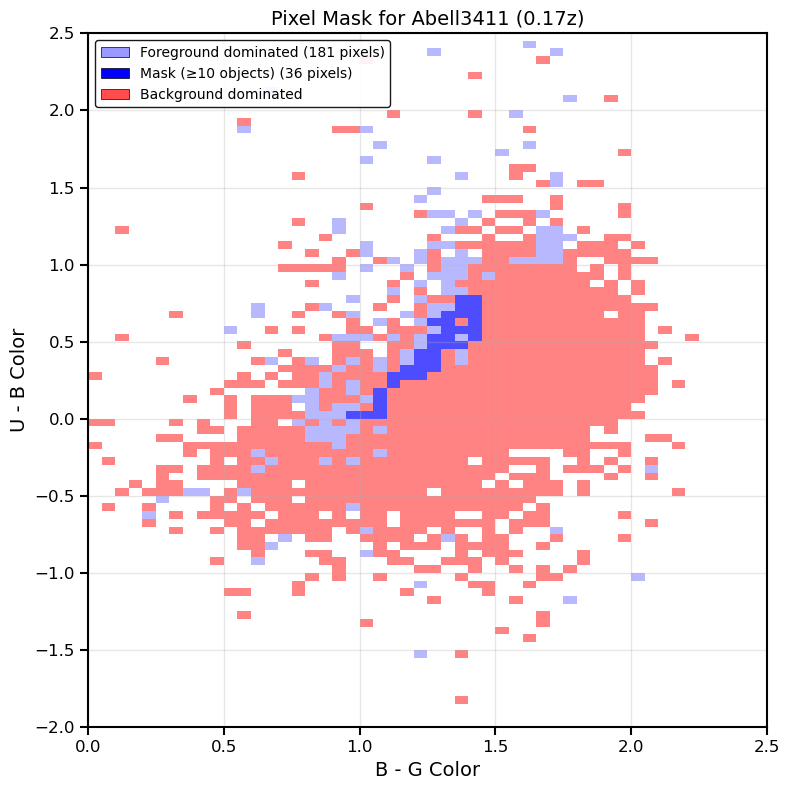


Pixel Mask Analysis:
Pixel size: 0.05
Total foreground pixels: 181
 Mask (blue with ≥10 objects): 36
Percentage of blue pixels with ≥10 objects: 19.9%


In [11]:
vote_map, x_edges, y_edges, bg_hist, fg_hist, total_objects = plot_pixel_voting_map(
    color_bg, color_ub, redshift, Z_THRESH, XLIM, YLIM,
    training_mask, CLUSTER_NAME,
    PIXEL_SIZE,
    PURITY_THRESHOLD,
    show_scatter=False,
    show_counts=False,
    show_mask=True,
    actual_catalog= f'{CLUSTER_NAME}_actual',
    redshift_seq=False,
    imposters_catalog= f'{CLUSTER_NAME}_imposter',
    figsize=(8, 8),
    weighting=False,             # Enable weighted purity
    color_bg_err=color_bg_err,   # B-G color errors
    color_ub_err=color_ub_err    # U-B color errors
)

## Write to File 

In [16]:

foreground_galaxies = apply_pixel_mask_to_catalog(
    vote_map_display=vote_map,
    x_edges=x_edges,
    y_edges=y_edges,
    full_catalog=full_cat,
    cluster_name=CLUSTER_NAME,
    pixel_size=PIXEL_SIZE,
    purity_threshold=PURITY_THRESHOLD,
    show_mask=True,
    save_to=FG_Path,
    pixel_with_redseq=False,
    actual_catalog=Abell3411_actual
)

Found 8708 objects for Abell3411
Objects with valid colors: 8708

Mask Application Results:
Total Abell3411 objects: 8708
Objects in masked pixels: 533 (6.1%)
  - In green pixels: 533
  - In magenta pixels: 0

Saved 533 foreground galaxies to /projects/mccleary_group/amit.m/dust/Abell3411_0.5_foreground_pixel_0.05.fits


## Extra Stuff with the Fits File

### Plot the foreground objects in RADEC space

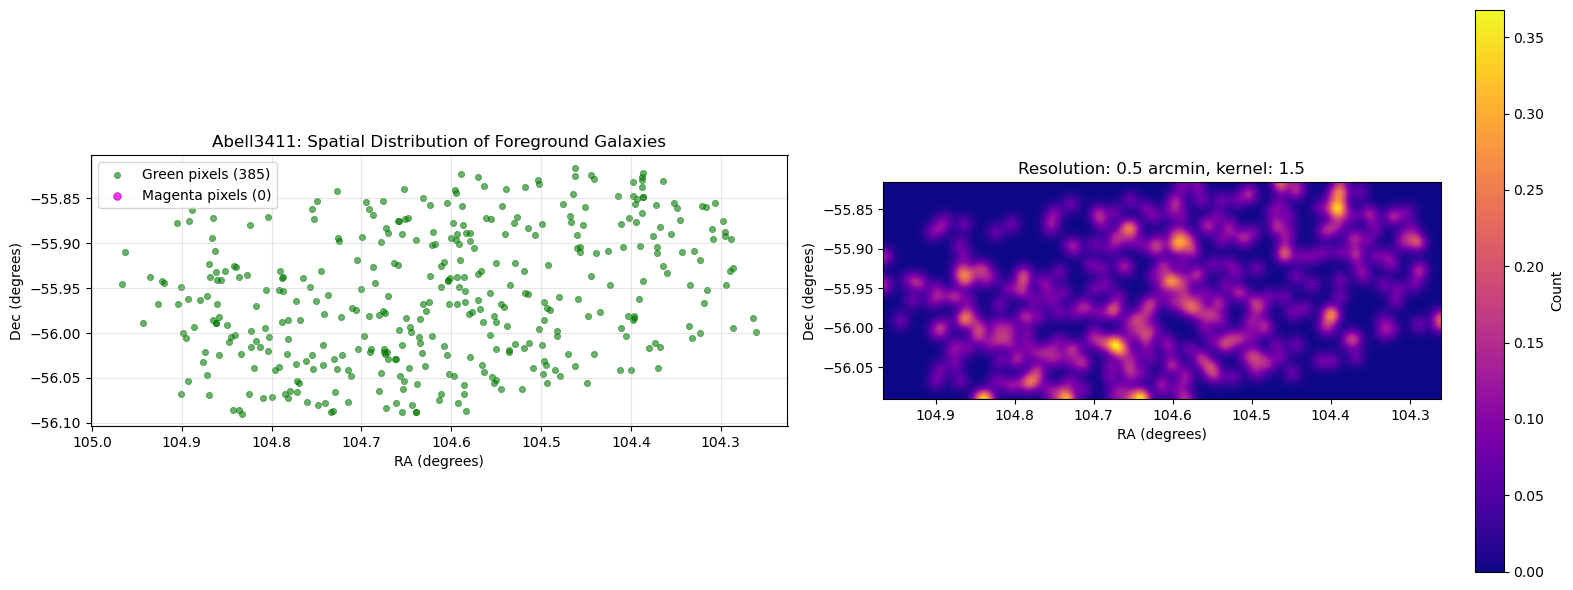

Loaded 588 foreground galaxies
Green pixels: 385, Magenta pixels: 0


In [17]:
result = spatial_plot('/projects/mccleary_group/amit.m/color_fg_data/1E0657_Bullet/foreground/1E0657_Bullet_0.75_foreground_pixel_0.05_and_redseq.fits', 
             vote_map, x_edges, y_edges, CLUSTER_NAME, include_members=False, actual_catalog = Abell3411_actual)

### Plot the Radius Distribution of the Foreground Objects 

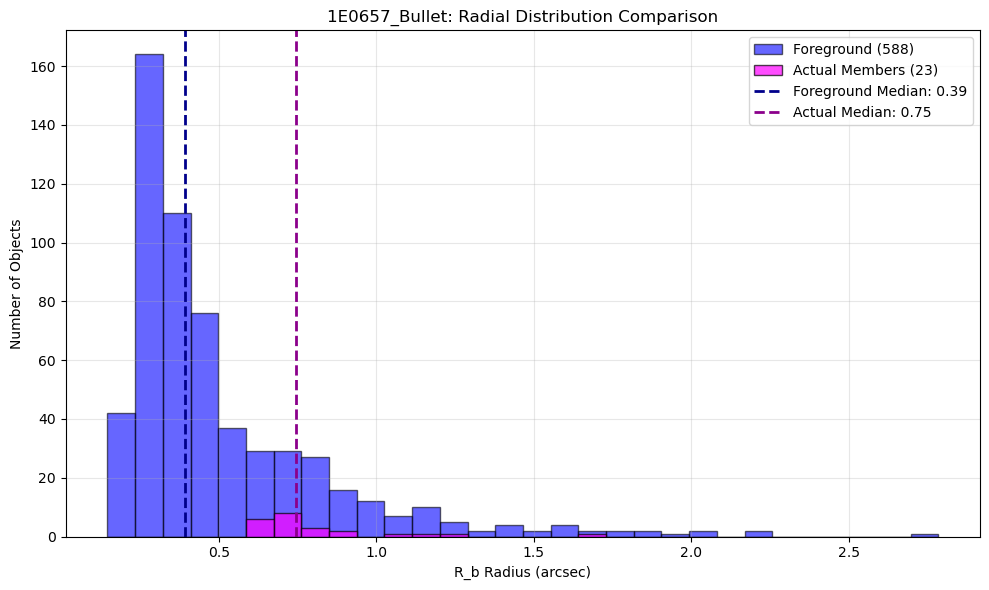

Foreground median radius: 0.39 arcsec
Actual members median radius: 0.75 arcsec


In [18]:

r_b_values = plot_radial_distribution_rb(
    '/projects/mccleary_group/amit.m/color_fg_data/1E0657_Bullet/foreground/1E0657_Bullet_0.75_foreground_pixel_0.05_and_redseq.fits',
    '1E0657_Bullet',
    actual_catalog=Bullet_actual
)

### Error Maps

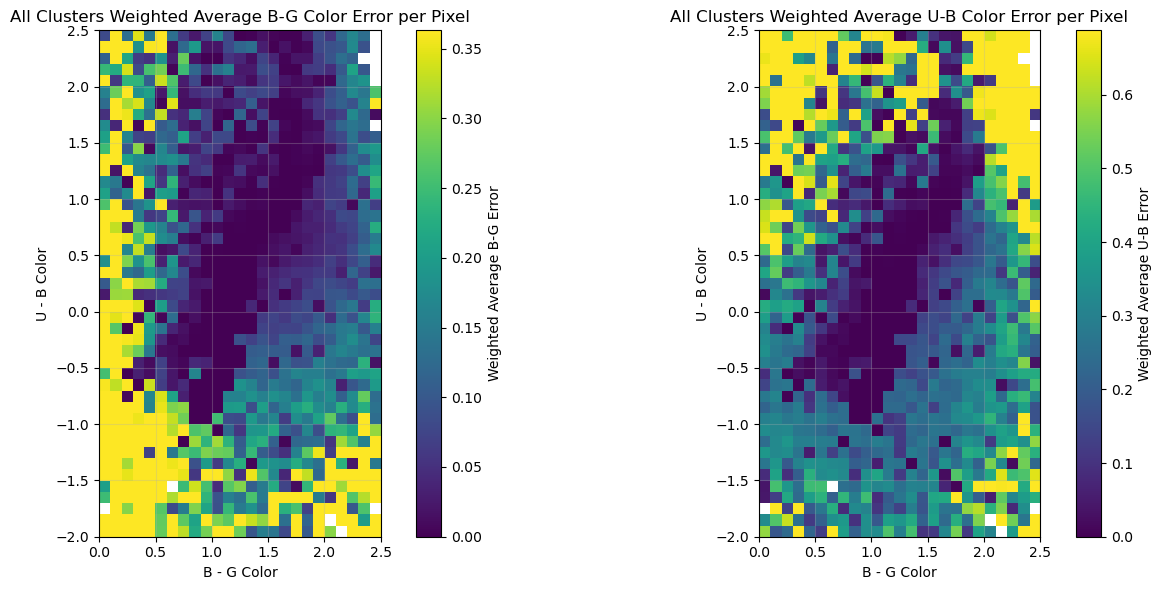


Pixel Error Map Analysis (Weighted Average mode):
Pixel size: 0.1
Total pixels with objects: 1113

B-G Error Statistics (Weighted Average):

Note: Weighted average gives more weight to precise measurements (1/error²)


(array([[1.00088108, 0.55562997,        nan, ..., 0.11248316, 0.48677741,
         0.08143126],
        [0.47955474, 0.82300183, 4.81183767, ..., 0.37927965, 0.40443432,
         0.78826377],
        [0.70325428, 2.99002552, 0.29666994, ..., 0.21328493, 0.43598907,
         0.13240642],
        ...,
        [0.37865597, 0.47544803, 0.10049634, ..., 0.11457728, 0.17254289,
         0.16714751],
        [1.34593284, 0.20085263, 0.26237133, ...,        nan, 0.09161492,
         0.1306953 ],
        [1.74043334, 0.78690073,        nan, ...,        nan,        nan,
                nan]]),
 array([[0.57549423, 0.33275977,        nan, ..., 0.66852141, 3.39381445,
         0.763865  ],
        [0.18536231, 0.49995142, 1.50416648, ..., 1.35036709, 1.40184896,
         6.55090311],
        [0.23753713, 0.63077979, 0.13484926, ..., 0.85834132, 3.72751694,
         0.4744568 ],
        ...,
        [0.37742856, 0.53887343, 0.080259  , ..., 1.98095601, 4.05666205,
         4.09366294],
        [1.3

In [19]:
plot_pixel_error_maps(
    color_bg_full, color_ub_full, color_bg_err_full, color_ub_err_full,
    XLIM, YLIM, training_mask=None, cluster_name = CLUSTER_NAME,
    pixel_size=0.1,
    vmax_percentile=85,  
    statistic='weighted',  
    figsize=(14, 6)
)


# Characterizing the Spectroscopic Training Sample
Before splitting into train/test, I wanna understand our data:
- How are redshifts distributed across sources?
- At different thresholds, what's the foreground/background balance?
- Where is our training data dense vs sparse (RA/DEC?

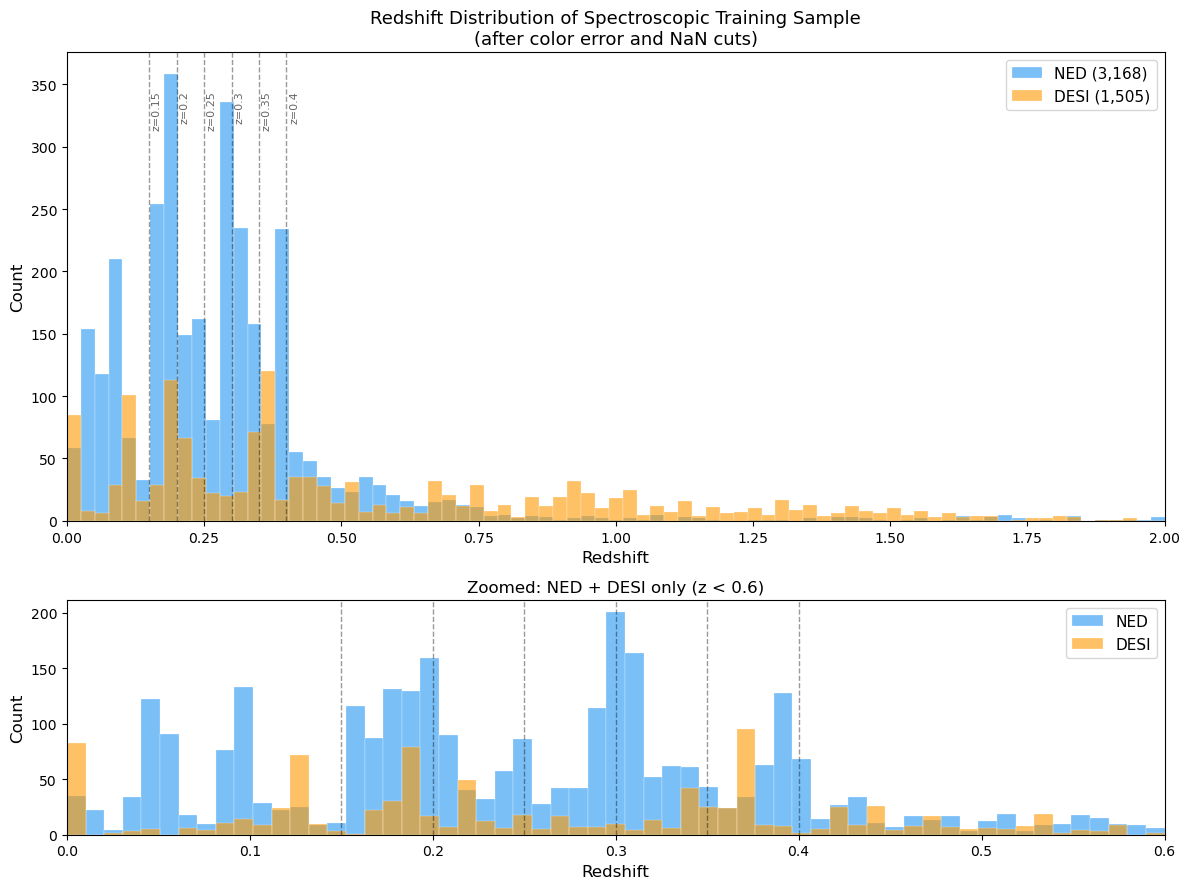


Sample Statistics (after quality cuts):
NED     : 3,168 objects | median z = 0.259 | range [-0.001, 6.640]
DESI    : 1,505 objects | median z = 0.373 | range [-0.000, 3.406]

NED+DESI: 4,673 objects | median z = 0.293


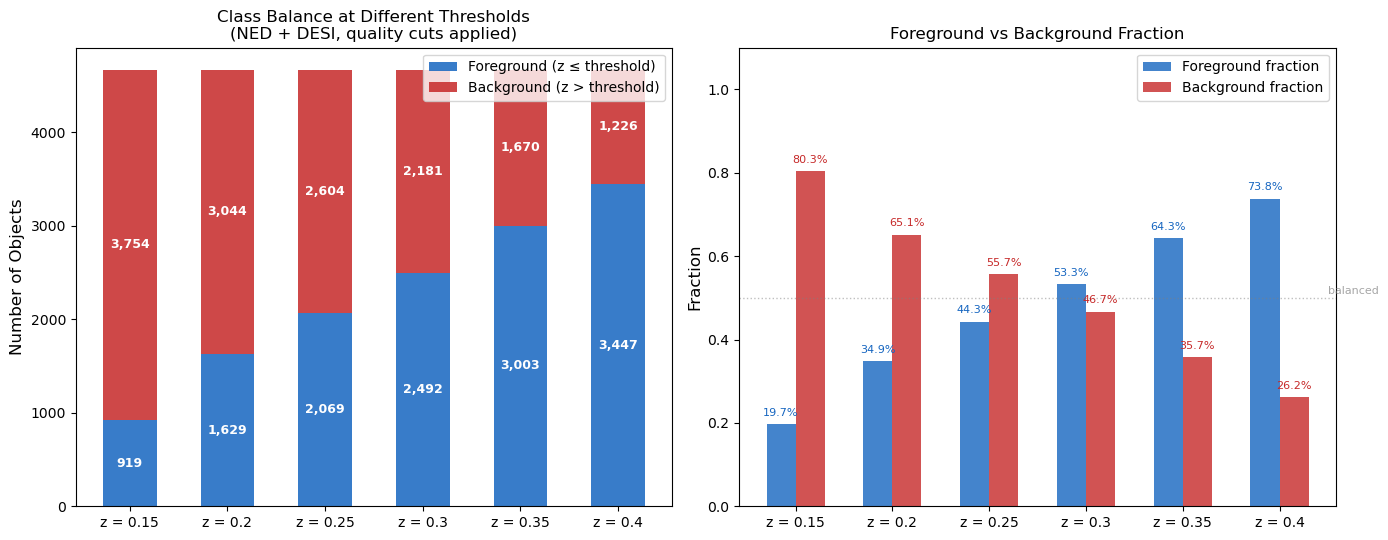


Class Balance Summary (NED + DESI):
 Threshold | Foreground | Background |  FG Frac | FG:BG Ratio
----------------------------------------------------------------------
  z = 0.15 |        919 |      3,754 |   19.7% |      0.24:1
   z = 0.2 |      1,629 |      3,044 |   34.9% |      0.54:1
  z = 0.25 |      2,069 |      2,604 |   44.3% |      0.79:1
   z = 0.3 |      2,492 |      2,181 |   53.3% |      1.14:1
  z = 0.35 |      3,003 |      1,670 |   64.3% |      1.80:1
   z = 0.4 |      3,447 |      1,226 |   73.8% |      2.81:1


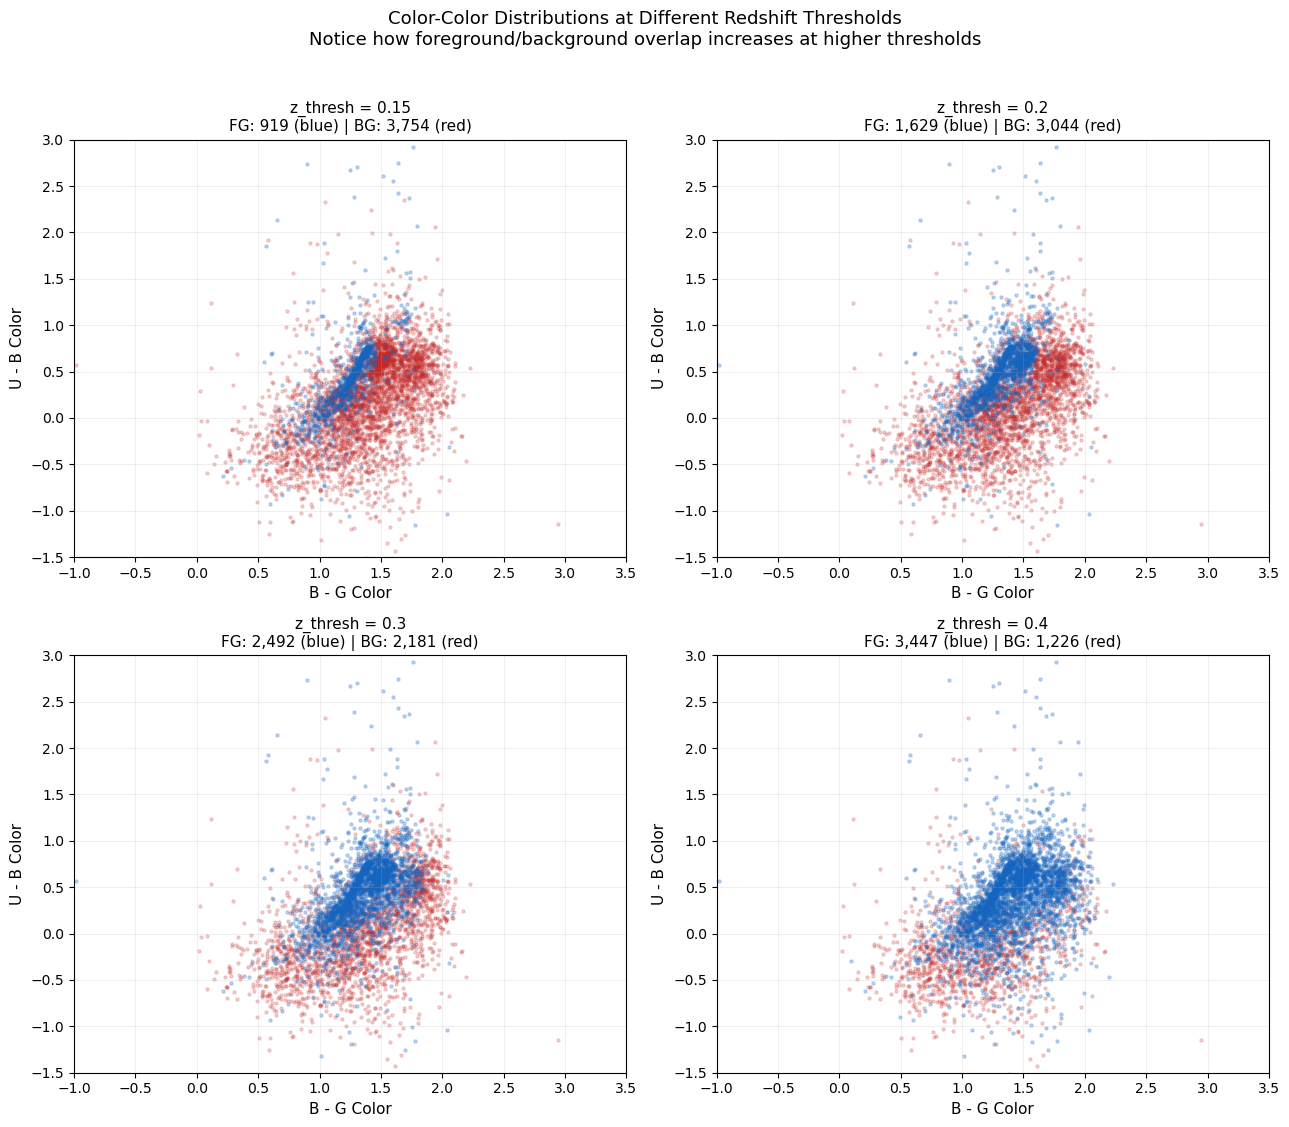

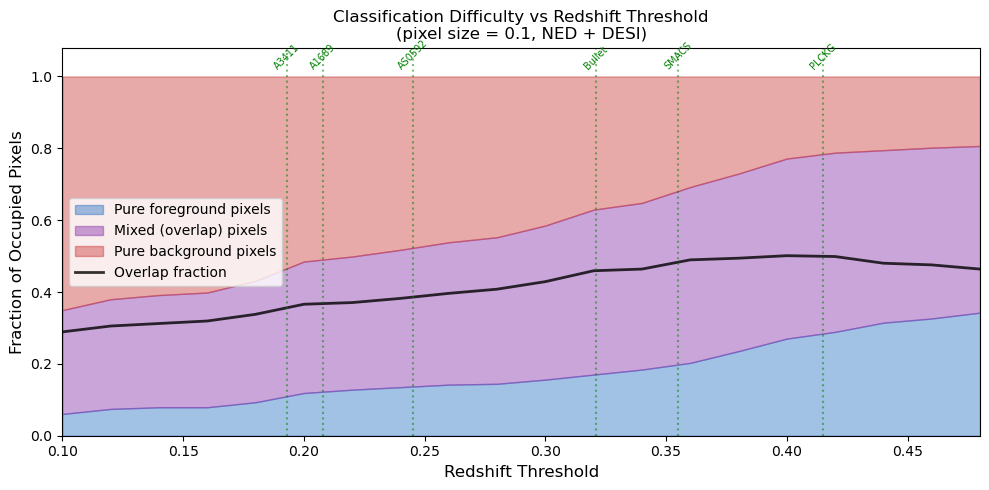


Interpretation:
- 'Pure' pixels contain ONLY fg or ONLY bg objects → easy to classify
- 'Mixed' pixels contain BOTH → these are where misclassification happens
- As threshold increases, more pixels become mixed → harder problem


In [13]:


# %%
# ============================================================
# Plot 1: Redshift Distribution by Source
# ============================================================
# Apply quality cuts (valid data + good colors) but keep ALL sources
# so we can see what we're excluding

good_mask = valid_data_mask & good_colors_mask #defined above

# Candidate redshift thresholds spanning your cluster range
# (Abell3411: 0.168, Abell1689: 0.183, Abell3411+buffer: 0.193, 
#  AbellS0592: 0.22, Bullet: 0.296, SMACS: 0.33, PLCKG: 0.39)
candidate_thresholds = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [2, 1]})

# --- Top panel: full histogram by source ---
ax = axes[0]
z_range = (0, 2.0)  # Focus on the relevant range
bins = np.linspace(z_range[0], z_range[1], 80)

sources = ['NED', 'DESI']
colors_src = {'NED': '#2196F3', 'DESI': '#FF9800'}

for src in sources:
    src_mask = (redshift_source == src) & good_mask
    ax.hist(redshift[src_mask], bins=bins, alpha=0.6, 
            label=f'{src} ({np.sum(src_mask):,})', color=colors_src[src], 
            edgecolor='white', linewidth=0.3)

# Mark candidate thresholds
for zt in candidate_thresholds:
    ax.axvline(zt, color='black', linestyle='--', alpha=0.4, linewidth=1)
    ax.text(zt + 0.005, ax.get_ylim()[1] * 0.92, f'z={zt}', 
            fontsize=8, rotation=90, va='top', alpha=0.6)

ax.set_xlabel('Redshift', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Redshift Distribution of Spectroscopic Training Sample\n'
             '(after color error and NaN cuts)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(z_range)

# --- Bottom panel: zoomed in on 0 to 0.5 where the action is ---
ax2 = axes[1]
bins_zoom = np.linspace(0, 0.6, 60)

# Only NED + DESI (the reliable sources)
for src in ['NED', 'DESI']:
    src_mask = (redshift_source == src) & good_mask
    ax2.hist(redshift[src_mask], bins=bins_zoom, alpha=0.6, 
             label=f'{src}', color=colors_src[src],
             edgecolor='white', linewidth=0.3)

for zt in candidate_thresholds:
    ax2.axvline(zt, color='black', linestyle='--', alpha=0.4, linewidth=1)

ax2.set_xlabel('Redshift', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Zoomed: NED + DESI only (z < 0.6)', fontsize=12)
ax2.legend(fontsize=11)
ax2.set_xlim(0, 0.6)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSample Statistics (after quality cuts):")
print("=" * 55)
for src in sources:
    src_mask = (redshift_source == src) & good_mask
    z_src = redshift[src_mask]
    if len(z_src) > 0:
        print(f"{src:8s}: {np.sum(src_mask):5,} objects | "
              f"median z = {np.nanmedian(z_src):.3f} | "
              f"range [{np.nanmin(z_src):.3f}, {np.nanmax(z_src):.3f}]")

# Combined NED + DESI
ned_desi_mask = ((redshift_source == 'NED') | (redshift_source == 'DESI')) & good_mask
z_nd = redshift[ned_desi_mask]
print(f"\n{'NED+DESI':8s}: {np.sum(ned_desi_mask):5,} objects | "
      f"median z = {np.nanmedian(z_nd):.3f}")

# %%
# ============================================================
# Plot 2: Class Balance at Different Redshift Thresholds
# ============================================================
# This shows how the foreground/background split changes as 
# we move the threshold -- critical for understanding what 
# the pixel mask is trying to do at each cluster's redshift.

# Use only NED + DESI with quality cuts (our actual training sample)
train_z = redshift[ned_desi_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Left panel: stacked bar chart of fg/bg counts ---
ax = axes[0]
n_fg = []
n_bg = []
for zt in candidate_thresholds:
    n_fg.append(np.sum(train_z <= zt))
    n_bg.append(np.sum(train_z > zt))

x_pos = np.arange(len(candidate_thresholds))
bar_width = 0.55

bars_fg = ax.bar(x_pos, n_fg, bar_width, label='Foreground (z ≤ threshold)', 
                 color='#1565C0', alpha=0.85)
bars_bg = ax.bar(x_pos, n_bg, bar_width, bottom=n_fg, 
                 label='Background (z > threshold)', 
                 color='#C62828', alpha=0.85)

# Add count labels on bars
for i, (fg, bg) in enumerate(zip(n_fg, n_bg)):
    total = fg + bg
    # Foreground count
    ax.text(i, fg / 2, f'{fg:,}', ha='center', va='center', 
            fontsize=9, fontweight='bold', color='white')
    # Background count
    ax.text(i, fg + bg / 2, f'{bg:,}', ha='center', va='center', 
            fontsize=9, fontweight='bold', color='white')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'z = {zt}' for zt in candidate_thresholds], fontsize=10)
ax.set_ylabel('Number of Objects', fontsize=12)
ax.set_title('Class Balance at Different Thresholds\n(NED + DESI, quality cuts applied)', 
             fontsize=12)
ax.legend(fontsize=10, loc='upper right')

# --- Right panel: foreground fraction and class ratio ---
ax2 = axes[1]

fg_fractions = [fg / (fg + bg) for fg, bg in zip(n_fg, n_bg)]
bg_fractions = [bg / (fg + bg) for fg, bg in zip(n_fg, n_bg)]
ratios = [fg / bg if bg > 0 else np.inf for fg, bg in zip(n_fg, n_bg)]

color_fg = '#1565C0'
color_ratio = '#6A1B9A'

ax2.bar(x_pos - 0.15, fg_fractions, 0.3, label='Foreground fraction', 
        color=color_fg, alpha=0.8)
ax2.bar(x_pos + 0.15, bg_fractions, 0.3, label='Background fraction', 
        color='#C62828', alpha=0.8)

# Add a horizontal line at 0.5 (balanced)
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax2.text(len(candidate_thresholds) - 0.5, 0.51, 'balanced', 
         fontsize=8, color='gray', alpha=0.7)

# Add fraction labels
for i, (ff, bf) in enumerate(zip(fg_fractions, bg_fractions)):
    ax2.text(i - 0.15, ff + 0.02, f'{ff:.1%}', ha='center', fontsize=8, color=color_fg)
    ax2.text(i + 0.15, bf + 0.02, f'{bf:.1%}', ha='center', fontsize=8, color='#C62828')

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'z = {zt}' for zt in candidate_thresholds], fontsize=10)
ax2.set_ylabel('Fraction', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.set_title('Foreground vs Background Fraction', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print table
print("\nClass Balance Summary (NED + DESI):")
print("=" * 70)
print(f"{'Threshold':>10} | {'Foreground':>10} | {'Background':>10} | {'FG Frac':>8} | {'FG:BG Ratio':>11}")
print("-" * 70)
for zt, fg, bg, ff in zip(candidate_thresholds, n_fg, n_bg, fg_fractions):
    ratio_str = f"{fg/bg:.2f}:1" if bg > 0 else "inf"
    print(f"{'z = ' + str(zt):>10} | {fg:>10,} | {bg:>10,} | {ff:>7.1%} | {ratio_str:>11}")

# %%
# ============================================================
# Plot 3: Color-Color Density at Different Thresholds
# ============================================================
# Shows how the foreground and background populations shift 
# in color-color space as the threshold changes.
# This is the physical heart of why validation at multiple 
# thresholds matters.

train_bg_colors = color_bg[ned_desi_mask]
train_ub_colors = color_ub[ned_desi_mask]

viz_thresholds = [0.15, 0.2, 0.3, 0.4]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for idx, zt in enumerate(viz_thresholds):
    ax = axes[idx]
    
    fg_mask = train_z <= zt
    bg_mask = train_z > zt
    
    if np.sum(bg_mask) > 0:
        ax.scatter(train_bg_colors[bg_mask], train_ub_colors[bg_mask],
                  c='#C62828', alpha=0.2, s=5, rasterized=True)
    
    if np.sum(fg_mask) > 0:
        ax.scatter(train_bg_colors[fg_mask], train_ub_colors[fg_mask],
                  c='#1565C0', alpha=0.25, s=5, rasterized=True)
    
    n_fg_here = np.sum(fg_mask)
    n_bg_here = np.sum(bg_mask)
    
    ax.set_xlim(-1, 3.5)
    ax.set_ylim(-1.5, 3)
    ax.set_xlabel('B - G Color', fontsize=11)
    ax.set_ylabel('U - B Color', fontsize=11)
    ax.set_title(f'z_thresh = {zt}\n'
                 f'FG: {n_fg_here:,} (blue) | BG: {n_bg_here:,} (red)', 
                 fontsize=11)
    ax.grid(True, alpha=0.2)

fig.suptitle('Color-Color Distributions at Different Redshift Thresholds\n'
             'Notice how foreground/background overlap increases at higher thresholds',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
# %%
# ============================================================
# Plot 4: Overlap Quantification
# ============================================================
# For each threshold, compute what fraction of color-color pixels
# have BOTH foreground and background objects. This directly 
# measures how hard the classification problem is.

pixel_size_test = 0.1  # Same as your pixel mask
overlap_fractions = []
pure_fg_fractions = []
pure_bg_fractions = []

test_thresholds = np.arange(0.10, 0.50, 0.02)

for zt in test_thresholds:
    fg_mask = train_z <= zt
    bg_mask = train_z > zt
    
    bg_vals = train_bg_colors
    ub_vals = train_ub_colors
    
    # Define grid
    bg_bins = np.arange(-1, 3.5, pixel_size_test)
    ub_bins = np.arange(-1.5, 3, pixel_size_test)
    
    # Histogram foreground and background separately
    H_fg, _, _ = np.histogram2d(bg_vals[fg_mask], ub_vals[fg_mask], 
                                 bins=[bg_bins, ub_bins])
    H_bg, _, _ = np.histogram2d(bg_vals[bg_mask], ub_vals[bg_mask], 
                                 bins=[bg_bins, ub_bins])
    
    # Count pixel types (only among occupied pixels)
    occupied = (H_fg > 0) | (H_bg > 0)
    n_occupied = np.sum(occupied)
    
    if n_occupied > 0:
        both = np.sum((H_fg > 0) & (H_bg > 0))
        only_fg = np.sum((H_fg > 0) & (H_bg == 0))
        only_bg = np.sum((H_fg == 0) & (H_bg > 0))
        
        overlap_fractions.append(both / n_occupied)
        pure_fg_fractions.append(only_fg / n_occupied)
        pure_bg_fractions.append(only_bg / n_occupied)
    else:
        overlap_fractions.append(0)
        pure_fg_fractions.append(0)
        pure_bg_fractions.append(0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(test_thresholds, 0, pure_fg_fractions, 
                alpha=0.4, color='#1565C0', label='Pure foreground pixels')
ax.fill_between(test_thresholds, pure_fg_fractions, 
                np.array(pure_fg_fractions) + np.array(overlap_fractions),
                alpha=0.4, color='#7B1FA2', label='Mixed (overlap) pixels')
ax.fill_between(test_thresholds, 
                np.array(pure_fg_fractions) + np.array(overlap_fractions), 1,
                alpha=0.4, color='#C62828', label='Pure background pixels')

ax.plot(test_thresholds, overlap_fractions, 'k-', linewidth=2, 
        label='Overlap fraction', alpha=0.8)

# Mark your cluster redshifts
cluster_redshifts = {
    'A3411': 0.168, 'A1689': 0.183, 'AS0592': 0.22, 
    'Bullet': 0.296, 'SMACS': 0.33, 'PLCKG': 0.39
}
for name, zc in cluster_redshifts.items():
    zt_eff = zc + 0.025  # Your cluster thickness buffer
    if test_thresholds[0] <= zt_eff <= test_thresholds[-1]:
        ax.axvline(zt_eff, color='green', linestyle=':', alpha=0.5)
        ax.text(zt_eff, 1.02, name, fontsize=7, ha='center', 
                color='green', rotation=45)

ax.set_xlabel('Redshift Threshold', fontsize=12)
ax.set_ylabel('Fraction of Occupied Pixels', fontsize=12)
ax.set_title(f'Classification Difficulty vs Redshift Threshold\n'
             f'(pixel size = {pixel_size_test}, NED + DESI)', fontsize=12)
ax.legend(fontsize=10, loc='center left')
ax.set_xlim(test_thresholds[0], test_thresholds[-1])
ax.set_ylim(0, 1.08)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- 'Pure' pixels contain ONLY fg or ONLY bg objects → easy to classify")
print("- 'Mixed' pixels contain BOTH → these are where misclassification happens")
print("- As threshold increases, more pixels become mixed → harder problem")

# Validation Pipeline

## K - Fold Cross Validation

In [54]:

Z_THRESHOLDS = [0.15, 0.193, 0.2, 0.25, 0.3, 0.35, 0.4]

VISUALIZATION_Z = 0.35  # z threshold to use for the 3 contamination plot B

METHODS        = ['unweighted', 'weighted']

TAU_VALUES     = np.arange(0.50, 0.91, 0.05)   # [0.5, 0.6, 0.7, 0.8, 0.9]

VALIDATION_TAU = PURITY_THRESHOLD              # fixed tau used for the 2×2 summary plot

N_FOLDS        = 5

RANDOM_STATE   = 42


In [45]:
# HELPER FUNCTIONS

def classify_test_objects(vote_map, x_edges, y_edges, actual_counts,
                          test_bg, test_ub, min_count=10):
    """
    Classify test objects using a pre-built pixel mask.
    Returns predictions array: 1 = foreground (masked), 0 = background (kept).
    """
    predictions = np.zeros(len(test_bg), dtype=int)
    for idx in range(len(test_bg)):
        i = np.searchsorted(x_edges, test_bg[idx]) - 1
        j = np.searchsorted(y_edges, test_ub[idx]) - 1
        if 0 <= i < vote_map.shape[0] and 0 <= j < vote_map.shape[1]:
            if vote_map[i, j] == -1 and actual_counts[i, j] >= min_count:
                predictions[idx] = 1
    return predictions

def compute_metrics(true_labels, predictions):
    """
    Classification metrics for weak lensing source selection.
    Convention: 1 = foreground (removed), 0 = background (kept).
 
    bg_purity      : TN / (TN + FN)  — of objects we KEEP, fraction truly background
    bg_completeness: TN / (TN + FP)  — of all true background, fraction we keep
    fg_completeness: TP / (TP + FN)  — of all true foreground, fraction we catch
    fg_precision   : TP / (TP + FP)  — of objects we REMOVE, fraction truly foreground
    contamination  : FN / (TN + FN)  — foreground leakage into background sample
    """
    TP = np.sum((predictions == 1) & (true_labels == 1))
    FP = np.sum((predictions == 1) & (true_labels == 0))
    TN = np.sum((predictions == 0) & (true_labels == 0))
    FN = np.sum((predictions == 0) & (true_labels == 1))
 
    bg_purity       = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    bg_completeness = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    fg_completeness = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fg_precision    = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    contamination   = FN / (TN + FN) if (TN + FN) > 0 else 0.0
 
    return {
        'bg_purity': bg_purity, 'bg_completeness': bg_completeness,
        'fg_completeness': fg_completeness, 'fg_precision': fg_precision,
        'contamination': contamination,
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
    }

def compute_three_contaminations(fold_metrics_list):
    """
    From a list of fold metric dicts, compute means and stds of:
      bg_contam   : FN / (TN + FN)         — BG contamination (FG→BG)
      fg_contam   : FP / (TP + FP)         — FG contamination (BG→FG)
      total_contam: (FP + FN) / total      — total misclassification
      bg_comp     : TN / (TN + FP)         — background completeness
    """
    bg_contam, fg_contam, total_contam, bg_comp = [], [], [], []
 
    for f in fold_metrics_list:
        TP, FP, TN, FN = f['TP'], f['FP'], f['TN'], f['FN']
        total = TP + FP + TN + FN
        bg_contam.append(FN / (TN + FN) if (TN + FN) > 0 else 0)
        fg_contam.append(FP / (TP + FP) if (TP + FP) > 0 else 0)
        total_contam.append((FP + FN) / total if total > 0 else 0)
        bg_comp.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
 
    return {
        'bg_contam_mean':    np.mean(bg_contam),    'bg_contam_std':    np.std(bg_contam),
        'fg_contam_mean':    np.mean(fg_contam),    'fg_contam_std':    np.std(fg_contam),
        'total_contam_mean': np.mean(total_contam), 'total_contam_std': np.std(total_contam),
        'bg_comp_mean':      np.mean(bg_comp),      'bg_comp_std':      np.std(bg_comp),
    }

## Cross Validation Loop


In [32]:

#  QUALITY FILTERING

q_bg = color_bg[training_mask]
q_ub = color_ub[training_mask]
q_z = redshift[training_mask]
q_bg_err = color_bg_err[training_mask]
q_ub_err = color_ub_err[training_mask]

print(f"Total quality-filtered objects for CV: {len(q_z)}")
print(f"  NED: {np.sum(redshift_source[training_mask] == 'NED')}")
print(f"  DESI: {np.sum(redshift_source[training_mask] == 'DESI')}")

Total quality-filtered objects for CV: 4673
  NED: 3168
  DESI: 1505


In [46]:
# results_all[method][z_thresh][tau] = list of fold metric dicts (length N_FOLDS)
results_all = {m: {z: {tau: [] for tau in TAU_VALUES}
                   for z in Z_THRESHOLDS}
               for m in METHODS}
 
total_runs = N_FOLDS * len(Z_THRESHOLDS) * len(TAU_VALUES) * len(METHODS)
run_count  = 0
print(f"\nRunning {N_FOLDS}-fold stratified CV across "
      f"{len(Z_THRESHOLDS)} thresholds × {len(TAU_VALUES)} tau values × {len(METHODS)} methods...")
print(f"Total evaluations: {total_runs}\n")
 
for z_thresh in Z_THRESHOLDS:
    labels = (q_z <= z_thresh).astype(int)
    n_fg   = np.sum(labels == 1)
    n_bg   = np.sum(labels == 0)
    print(f"z_thresh = {z_thresh:.3f}  |  {n_fg} foreground, {n_bg} background")
 
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
 
    for method in METHODS:
        use_weighting = (method == 'weighted')
 
        for fold, (train_idx, test_idx) in enumerate(skf.split(q_bg, labels)):
            test_bg    = q_bg[test_idx]
            test_ub    = q_ub[test_idx]
            true_labels = (q_z[test_idx] <= z_thresh).astype(int)
 
            for tau in TAU_VALUES:
                kwargs = dict(
                    color_bg=q_bg[train_idx],
                    color_ub=q_ub[train_idx],
                    redshift=q_z[train_idx],
                    z_thresh=z_thresh,
                    xlim=XLIM, ylim=YLIM,
                    pixel_size=PIXEL_SIZE,
                    purity_threshold=tau,
                    training_mask=None,
                    weighting=use_weighting,
                )
                if use_weighting:
                    kwargs['color_bg_err'] = q_bg_err[train_idx]
                    kwargs['color_ub_err'] = q_ub_err[train_idx]
 
                with redirect_stdout(io.StringIO()):
                    vote_map, x_edges, y_edges, bg_hist, fg_hist, total_objects, actual_counts = create_pixel_voting_map_purity(**kwargs)
 
                predictions = classify_test_objects(
                    vote_map, x_edges, y_edges, actual_counts,
                    test_bg, test_ub, min_count=MIN_COUNT
                )
                results_all[method][z_thresh][tau].append(
                    compute_metrics(true_labels, predictions)
                )
                run_count += 1
 
print(f"\nDone! {run_count} total evaluations")
 


Running 5-fold stratified CV across 7 thresholds × 9 tau values × 2 methods...
Total evaluations: 630

z_thresh = 0.150  |  919 foreground, 3754 background
z_thresh = 0.193  |  1515 foreground, 3158 background
z_thresh = 0.200  |  1629 foreground, 3044 background
z_thresh = 0.250  |  2069 foreground, 2604 background
z_thresh = 0.300  |  2492 foreground, 2181 background
z_thresh = 0.350  |  3003 foreground, 1670 background
z_thresh = 0.400  |  3447 foreground, 1226 background

Done! 630 total evaluations


## Plot A — Summary: Metrics vs Redshift Threshold (fixed τ = VALIDATION_TAU)

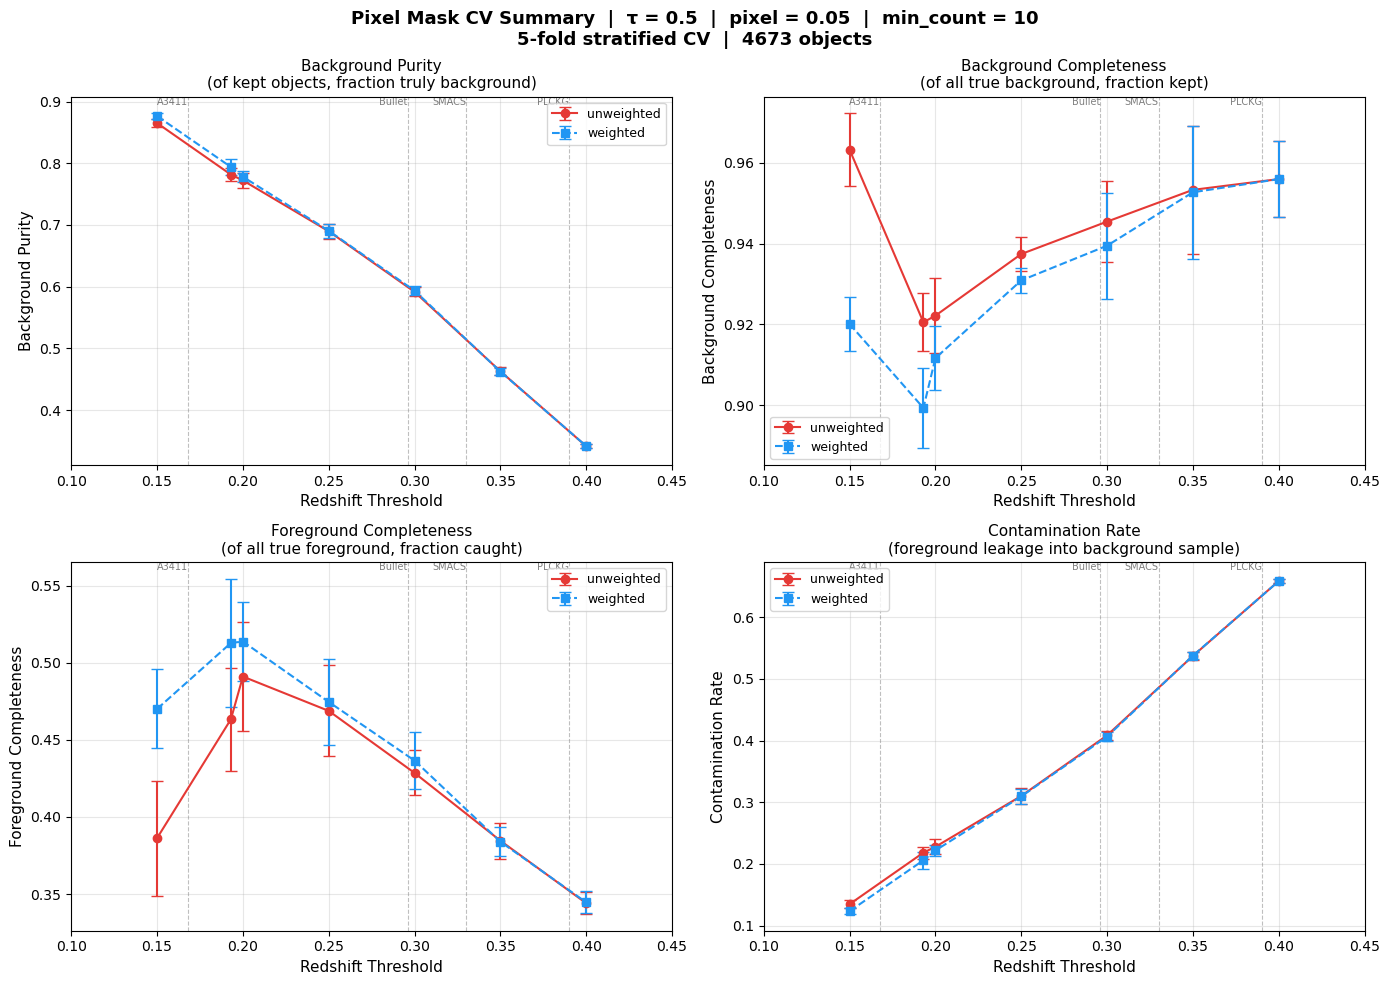


Saved: cv_summary_2x2.png


In [50]:
method_colors  = {'unweighted': '#E53935', 'weighted': '#2196F3'}
method_markers = {'unweighted': 'o',       'weighted': 's'}
method_ls      = {'unweighted': '-',       'weighted': '--'}
z_arr          = np.array(Z_THRESHOLDS)
cluster_z      = {'A3411': 0.168, 'Bullet': 0.296, 'SMACS': 0.33, 'PLCKG': 0.39}
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
metrics_2x2 = [
    ('bg_purity',       'Background Purity\n(of kept objects, fraction truly background)'),
    ('bg_completeness', 'Background Completeness\n(of all true background, fraction kept)'),
    ('fg_completeness', 'Foreground Completeness\n(of all true foreground, fraction caught)'),
    ('contamination',   'Contamination Rate\n(foreground leakage into background sample)'),
]
 
for ax_idx, (metric, title) in enumerate(metrics_2x2):
    ax = axes[ax_idx // 2][ax_idx % 2]
 
    for method in METHODS:
        means, stds = [], []
        for z_thresh in Z_THRESHOLDS:
            folds = results_all[method][z_thresh][VALIDATION_TAU]
            values = [f[metric] for f in folds]
            means.append(np.mean(values))
            stds.append(np.std(values))
 
        ax.errorbar(z_arr, means, yerr=stds,
                    color=method_colors[method], marker=method_markers[method],
                    linestyle=method_ls[method], markersize=6, capsize=4,
                    linewidth=1.5, label=method)
 
    for name, z_cl in cluster_z.items():
        ax.axvline(z_cl, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.text(z_cl, ax.get_ylim()[1] if ax.get_ylim()[1] < 1.0 else 0.98,
                name, fontsize=7, alpha=0.5, va='top', ha='right')
 
    ax.set_xlabel('Redshift Threshold', fontsize=11)
    ax.set_ylabel(' '.join(title.split('\n')[:1]), fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.10, 0.45)
 
plt.suptitle(
    f'Pixel Mask CV Summary  |  τ = {VALIDATION_TAU}  |  pixel = {PIXEL_SIZE}  |  min_count = {MIN_COUNT}\n'
    f'{N_FOLDS}-fold stratified CV  |  {len(q_z)} objects',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
#plt.savefig('cv_summary_2x2.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: cv_summary_2x2.png")
 


 ## Plot B — Three Contamination Metrics vs Background Completeness (τ sweep)

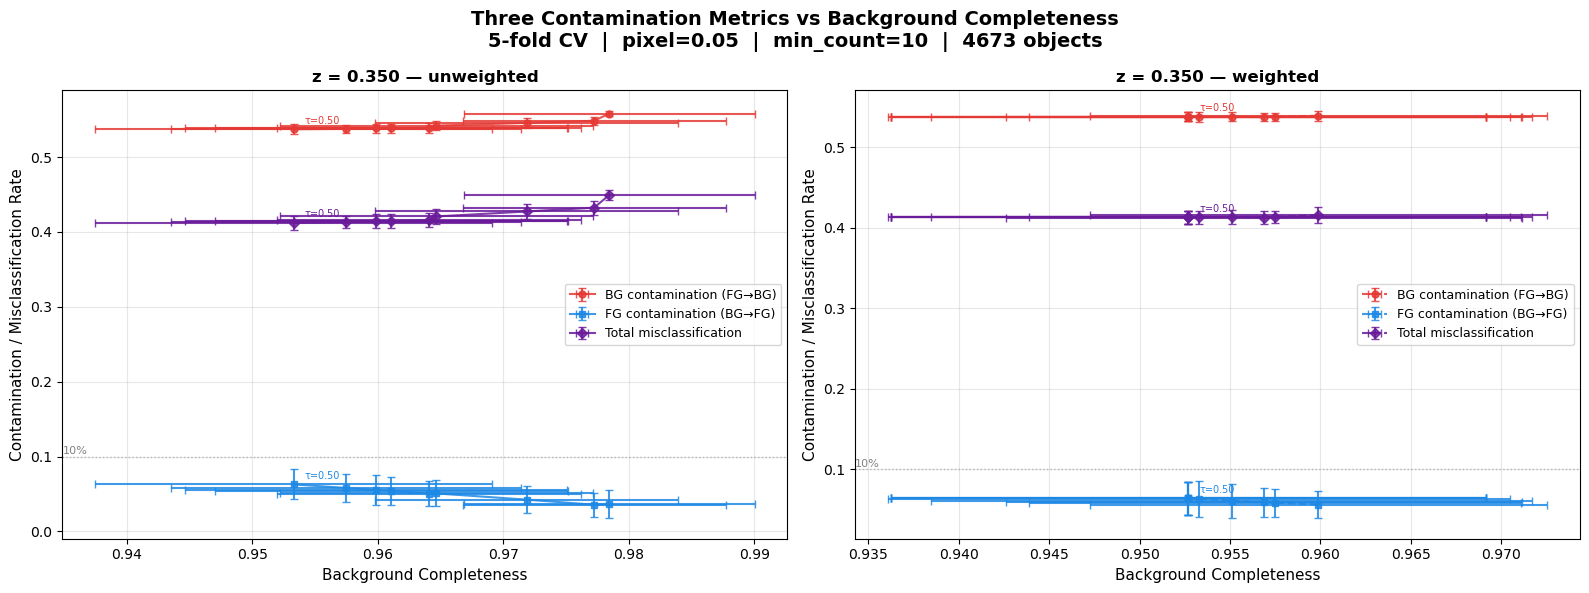


Saved: three_contaminations.png


In [55]:
contam_styles = {
    'bg_contam':    {'color': '#E53935', 'marker': 'o', 'label': 'BG contamination (FG→BG)'},
    'fg_contam':    {'color': '#1E88E5', 'marker': 's', 'label': 'FG contamination (BG→FG)'},
    'total_contam': {'color': '#6A1B9A', 'marker': 'D', 'label': 'Total misclassification'},
}
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
for col, method in enumerate(METHODS):
    ax = axes[col]
 
    for contam_type, style in contam_styles.items():
        means_x, means_y = [], []
        stds_x,  stds_y  = [], []
 
        for tau in TAU_VALUES:
            stats = compute_three_contaminations(results_all[method][VISUALIZATION_Z][tau])
            means_x.append(stats['bg_comp_mean'])
            stds_x.append(stats['bg_comp_std'])
            means_y.append(stats[f'{contam_type}_mean'])
            stds_y.append(stats[f'{contam_type}_std'])
 
        means_x = np.array(means_x)
        means_y = np.array(means_y)
        stds_x  = np.array(stds_x)
        stds_y  = np.array(stds_y)
 
        ax.errorbar(means_x, means_y, xerr=stds_x, yerr=stds_y,
                    color=style['color'], marker=style['marker'],
                    linestyle=method_ls[method], markersize=5,
                    capsize=3, linewidth=1.5, label=style['label'], alpha=0.85)
 
        # Annotate tau values
        for i, tau in enumerate(TAU_VALUES):
            if tau in [0.50, 0.75, 0.90]:
                ax.annotate(f'τ={tau:.2f}',
                            (means_x[i], means_y[i]),
                            textcoords='offset points', xytext=(8, 4),
                            fontsize=7, color=style['color'])
 
    # Medezinski 10% line
    ax.axhline(0.10, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    ax.text(ax.get_xlim()[0], 0.103, '10%', fontsize=8, color='gray')
 
    ax.set_xlabel('Background Completeness', fontsize=11)
    ax.set_ylabel('Contamination / Misclassification Rate', fontsize=11)
    ax.set_title(f'z = {VISUALIZATION_Z:.3f} — {method}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
 
plt.suptitle(
    f'Three Contamination Metrics vs Background Completeness\n'
    f'{N_FOLDS}-fold CV  |  pixel={PIXEL_SIZE}  |  min_count={MIN_COUNT}  |  {len(q_z)} objects',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
#plt.savefig('three_contaminations.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: three_contaminations.png")
 